DATASET LOADED
  Rows    : 307,511
  Columns : 122

TARGET VARIABLE : TARGET
  0 = Loan repaid on time (no default)
  1 = Client had payment difficulties (default)

Value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate : 8.07%
Non-default  : 91.93%


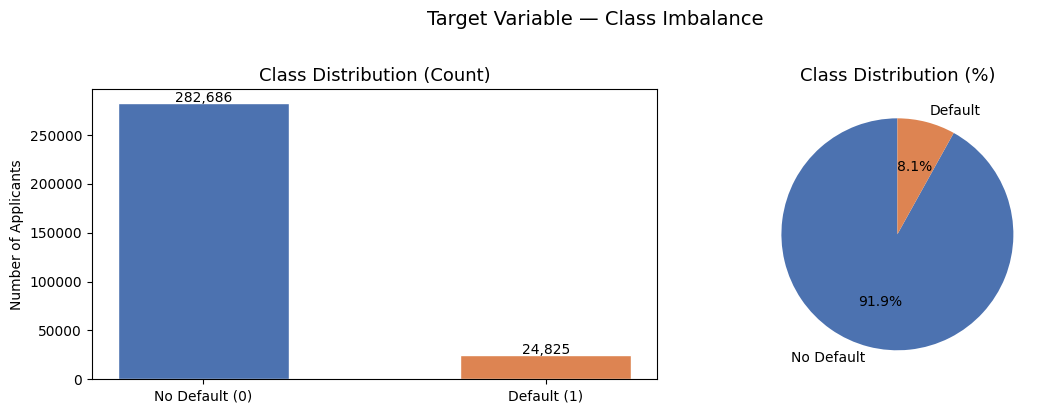


Chart saved as class_imbalance.png

EVALUATION METRICS — WHY EACH ONE IS USED

1. ROC-AUC (Area Under the ROC Curve)
   ─────────────────────────────────────
   Measures how well the model RANKS applicants by risk.
   AUC = 0.5 → random guessing
   AUC = 1.0 → perfect separation
   WHY: Works well even with class imbalance. A bank cares
        about ranking risk correctly, not just classifying.

2. KS Statistic (Kolmogorov-Smirnov)
   ─────────────────────────────────────
   Maximum separation between the cumulative distribution
   of defaulters vs non-defaulters across score deciles.
   WHY: Standard metric in credit risk industry. Directly
        tells you how well the model separates good vs bad.
   KS > 40% is considered a strong model in banking.

3. Business Loss Function
   ─────────────────────────────────────
   Cost of False Negative (missed default) >> 
   Cost of False Positive (rejected good customer)

   Example:
     Loan amount       = ₹5,00,000
     False Negative  

In [1]:
# ─────────────────────────────────────────────────────────────
# STEP 1 — PROBLEM FORMULATION
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Load the main training table ──────────────────────────────
df = pd.read_csv("data/raw/application_train.csv")

print("=" * 60)
print("DATASET LOADED")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("=" * 60)

# ── Target Variable ───────────────────────────────────────────
print("\nTARGET VARIABLE : TARGET")
print("  0 = Loan repaid on time (no default)")
print("  1 = Client had payment difficulties (default)")
print("\nValue counts:")
print(df["TARGET"].value_counts())

# ── Class Imbalance ───────────────────────────────────────────
target_counts = df["TARGET"].value_counts()
default_rate  = df["TARGET"].mean() * 100

print(f"\nDefault rate : {default_rate:.2f}%")
print(f"Non-default  : {100 - default_rate:.2f}%")

# ── Visualise Class Imbalance ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(
    ["No Default (0)", "Default (1)"],
    target_counts.values,
    color=["#4C72B0", "#DD8452"],
    edgecolor="white",
    width=0.5
)
axes[0].set_title("Class Distribution (Count)", fontsize=13)
axes[0].set_ylabel("Number of Applicants")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=["No Default", "Default"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=90
)
axes[1].set_title("Class Distribution (%)", fontsize=13)

plt.suptitle("Target Variable — Class Imbalance", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nChart saved as class_imbalance.png")

# ── Evaluation Metrics Explanation ───────────────────────────
print("""
=============================================================
EVALUATION METRICS — WHY EACH ONE IS USED
=============================================================

1. ROC-AUC (Area Under the ROC Curve)
   ─────────────────────────────────────
   Measures how well the model RANKS applicants by risk.
   AUC = 0.5 → random guessing
   AUC = 1.0 → perfect separation
   WHY: Works well even with class imbalance. A bank cares
        about ranking risk correctly, not just classifying.

2. KS Statistic (Kolmogorov-Smirnov)
   ─────────────────────────────────────
   Maximum separation between the cumulative distribution
   of defaulters vs non-defaulters across score deciles.
   WHY: Standard metric in credit risk industry. Directly
        tells you how well the model separates good vs bad.
   KS > 40% is considered a strong model in banking.

3. Business Loss Function
   ─────────────────────────────────────
   Cost of False Negative (missed default) >> 
   Cost of False Positive (rejected good customer)
   
   Example:
     Loan amount       = ₹5,00,000
     False Negative    = bank loses ₹5,00,000
     False Positive    = bank loses ₹15,000 (interest income)
   
   WHY: Pure accuracy is useless at 8% default rate.
        We optimize threshold to minimize total business loss.
=============================================================
""")

# ── Problem Type Summary ──────────────────────────────────────
print("""
ML PROBLEM TYPE
===============
Binary Classification
  Input  : Applicant features (income, age, credit history...)
  Output : Probability of default P(TARGET=1)
  
  We output a PROBABILITY (0 to 1), not just 0/1.
  The probability is then converted to a decision using
  a threshold optimized for business cost (Step 9).
""")

In [2]:
print(df.shape)
print(df["TARGET"].value_counts())
print(f"Default rate: {df['TARGET'].mean()*100:.2f}%")

(307511, 122)
TARGET
0    282686
1     24825
Name: count, dtype: int64
Default rate: 8.07%


STEP 2 — DATA UNDERSTANDING

[2A] COLUMN DATA TYPES
----------------------------------------
  float64         : 65 columns
  int64           : 41 columns
  str             : 16 columns

  Numerical columns   : 105
  Categorical columns : 16

[2B] MISSING VALUES — TOP 20 COLUMNS
----------------------------------------


C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\2699153321.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


  Total columns with missing values: 67

  Column                                         Missing %      Count
  -------------------------------------------------------------------
  COMMONAREA_AVG                                    69.9%    214,865
  COMMONAREA_MODE                                   69.9%    214,865
  COMMONAREA_MEDI                                   69.9%    214,865
  NONLIVINGAPARTMENTS_MEDI                          69.4%    213,514
  NONLIVINGAPARTMENTS_MODE                          69.4%    213,514
  NONLIVINGAPARTMENTS_AVG                           69.4%    213,514
  FONDKAPREMONT_MODE                                68.4%    210,295
  LIVINGAPARTMENTS_AVG                              68.4%    210,199
  LIVINGAPARTMENTS_MEDI                             68.4%    210,199
  LIVINGAPARTMENTS_MODE                             68.4%    210,199
  FLOORSMIN_MODE                                    67.8%    208,642
  FLOORSMIN_AVG                                     67.8%   

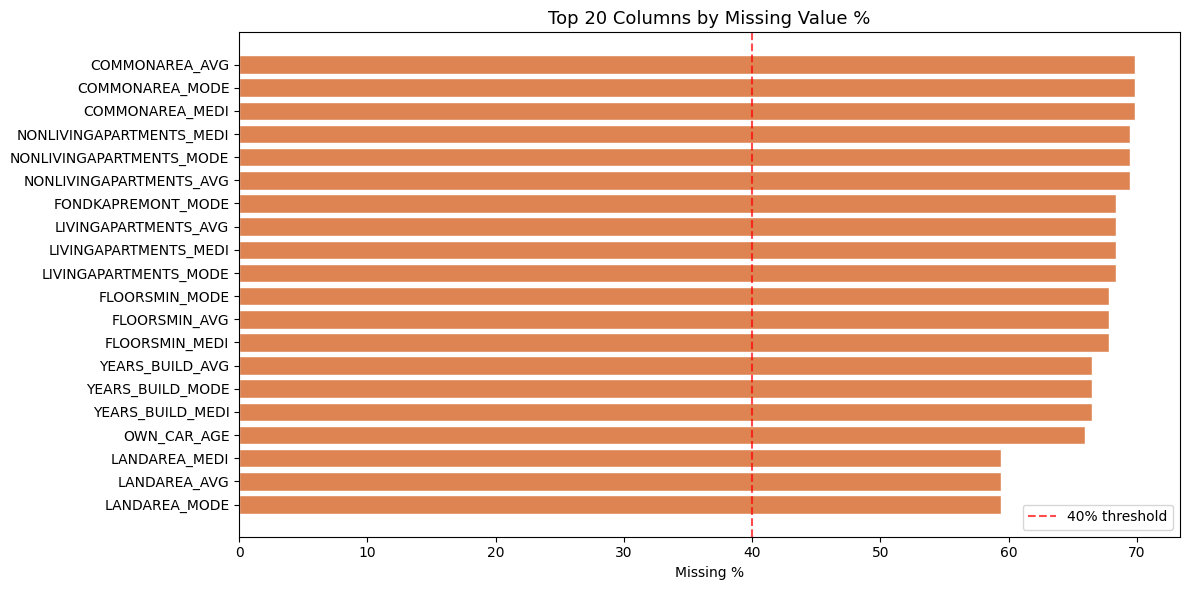


  Chart saved: missing_values.png

[2C] KEY NUMERICAL FEATURES — SUMMARY STATS
----------------------------------------
       AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  CNT_FAM_MEMBERS  CNT_CHILDREN
count      3.075110e+05   307511.00    307499.00        307233.00   307511.00      307511.00          307511.00        307511.00        307509.00     307511.00
mean       1.687979e+05   599026.00     27108.57        538396.21   -16037.00       63815.05           -4986.12         -2994.20             2.15          0.42
std        2.371231e+05   402490.78     14493.74        369446.46     4363.99      141275.77            3522.89          1509.45             0.91          0.72
min        2.565000e+04    45000.00      1615.50         40500.00   -25229.00      -17912.00          -24672.00         -7197.00             1.00          0.00
25%        1.125000e+05   270000.00     16524.00        238500.00   -19682.00  

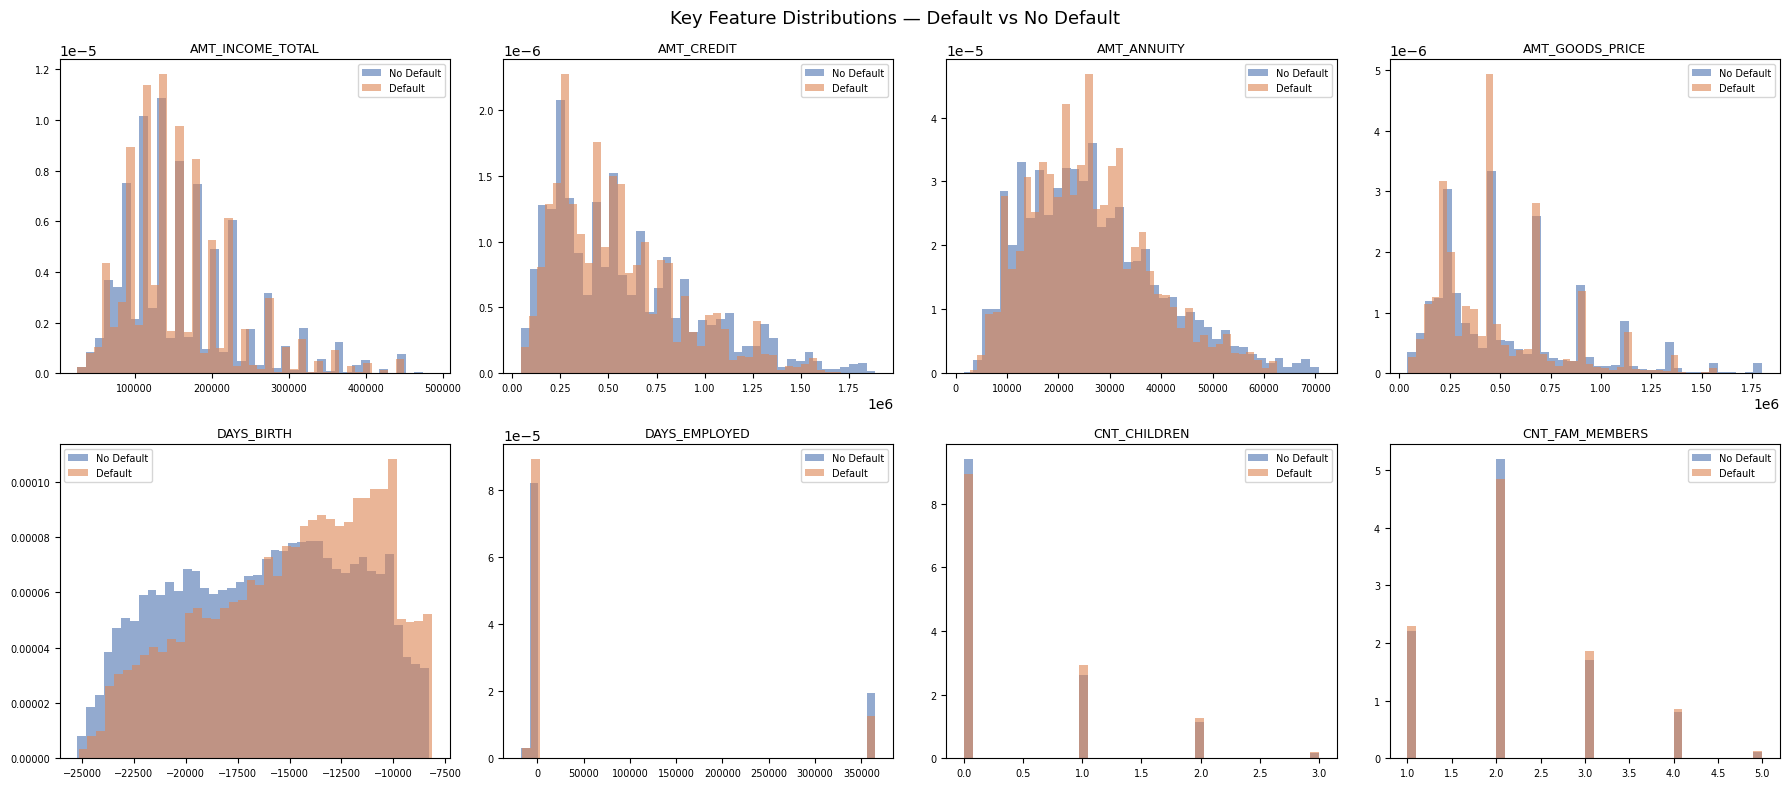

  Chart saved: feature_distributions.png

[2D] IMPORTANT DATA QUIRKS
----------------------------------------

  DAYS_BIRTH (stored as negative days):
    Min age : 20.5 years
    Max age : 69.1 years
    Mean age: 43.9 years

  DAYS_EMPLOYED anomaly (value=365243 means unemployed/retired):
    Count of anomalous rows : 55,374
    As % of dataset         : 18.0%

  'XNA' or 'Unknown' in categorical columns:
    CODE_GENDER                              XNA count: 4
    ORGANIZATION_TYPE                        XNA count: 55,374

[2E] TOP 15 NUMERICAL FEATURES CORRELATED WITH TARGET
----------------------------------------

  Feature                                         |Correlation|
  --------------------------------------------------------------
  EXT_SOURCE_3                                           0.1789
  EXT_SOURCE_2                                           0.1605
  EXT_SOURCE_1                                           0.1553
  DAYS_BIRTH                                      

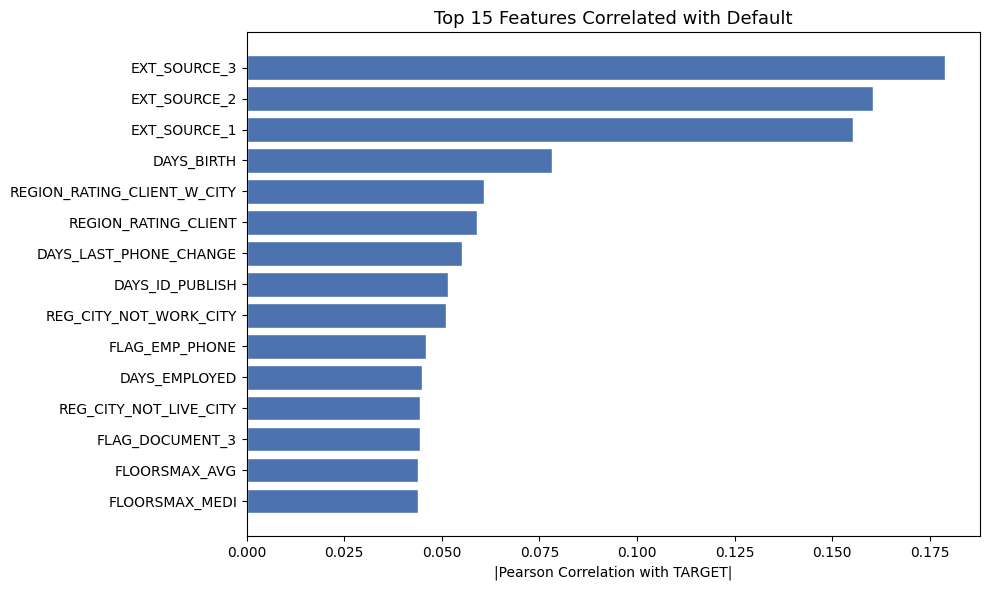

  Chart saved: correlation_with_target.png

[2F] CATEGORICAL FEATURES — DEFAULT RATE BY CATEGORY
----------------------------------------


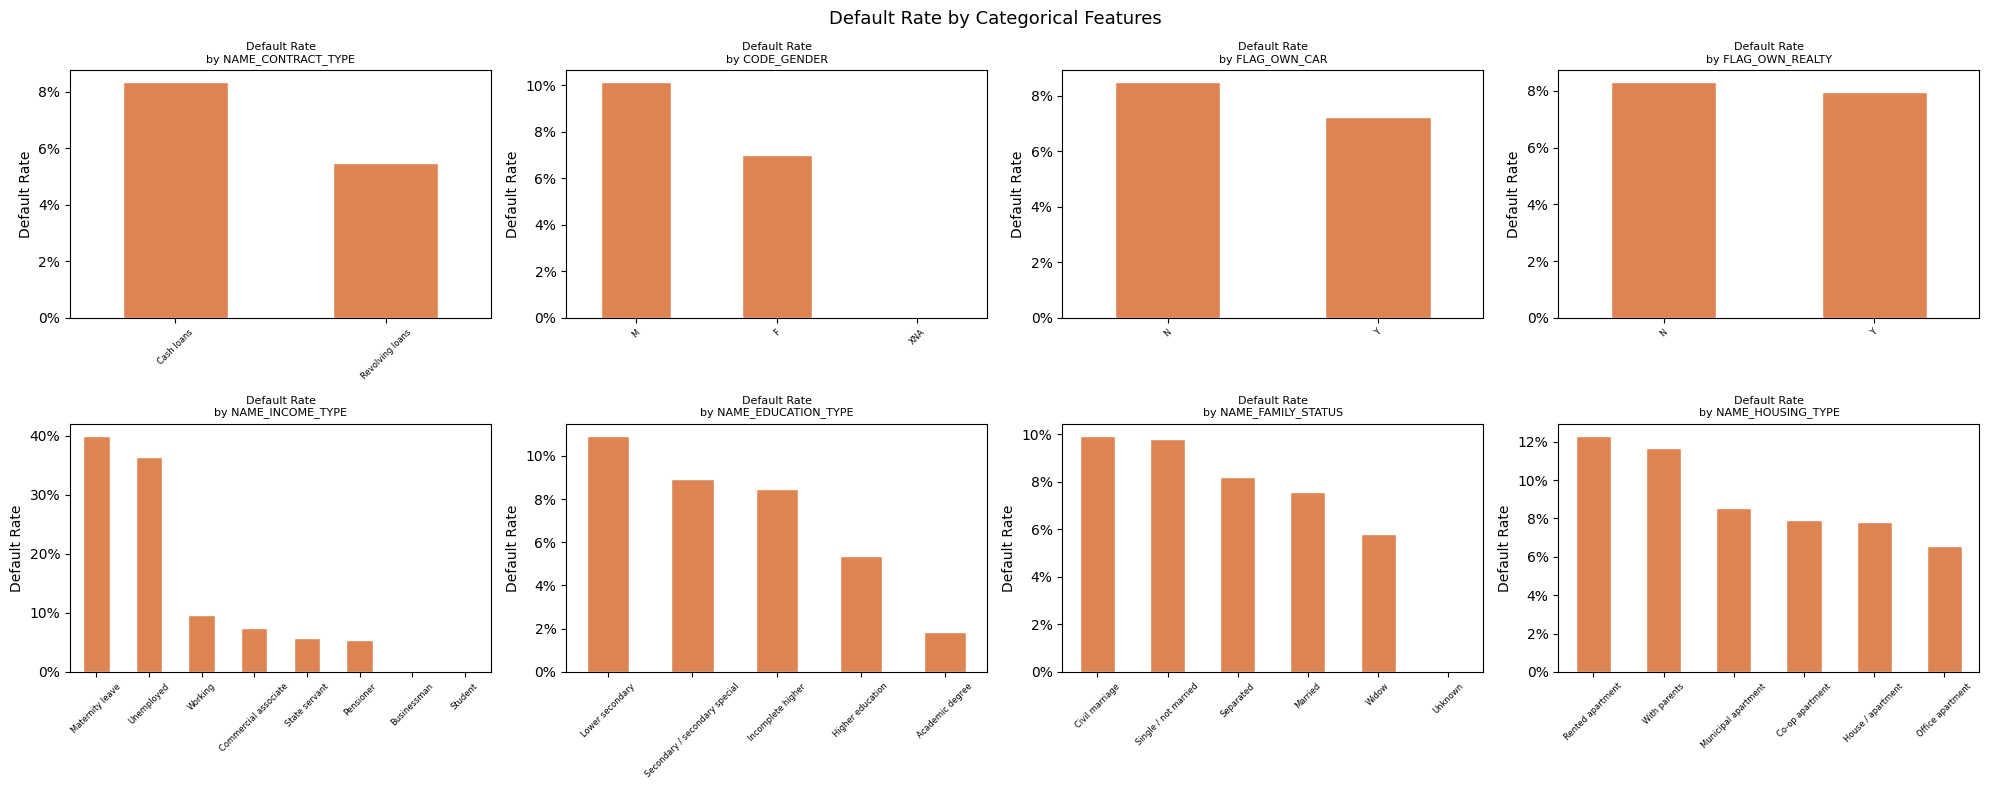

  Chart saved: categorical_default_rates.png

STEP 2 SUMMARY — KEY DATA RISKS IDENTIFIED

1. CLASS IMBALANCE (8.07% defaults)
   → Accuracy is misleading. Use AUC + KS.
   → Will use class_weight='balanced' in models.

2. MISSING VALUES
   → Many columns have 40-70% missing (e.g. OWN_CAR_AGE).
   → Strategy: median imputation + missing indicator flag.

3. DAYS_EMPLOYED ANOMALY
   → Value 365243 = unemployed/retired placeholder.
   → Must replace with NaN before any modeling.

4. DAYS_BIRTH IS NEGATIVE
   → Convert to positive age in years for interpretability.

5. XNA IN CATEGORICAL COLUMNS
   → Treat XNA as a separate valid category or as missing.

6. OUTLIERS IN INCOME / CREDIT
   → Some incomes are extremely high (data entry errors).
   → Will cap at 99th percentile during cleaning.

7. LOW RAW CORRELATIONS
   → No single feature has correlation > 0.15 with TARGET.
   → Tree-based models + feature interactions will be key.

[STEP 2 COMPLETE]


In [3]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — DATA UNDERSTANDING
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("=" * 60)
print("STEP 2 — DATA UNDERSTANDING")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 2A. BASIC SHAPE & COLUMN TYPES
# ─────────────────────────────────────────────────────────────

print("\n[2A] COLUMN DATA TYPES")
print("-" * 40)
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {str(dtype):<15} : {count} columns")

numerical_cols   = df.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target from feature lists
numerical_cols = [c for c in numerical_cols if c != "TARGET"]

print(f"\n  Numerical columns   : {len(numerical_cols)}")
print(f"  Categorical columns : {len(categorical_cols)}")


# ─────────────────────────────────────────────────────────────
# 2B. MISSING VALUES
# ─────────────────────────────────────────────────────────────

print("\n[2B] MISSING VALUES — TOP 20 COLUMNS")
print("-" * 40)

missing = df.isnull().mean().sort_values(ascending=False)
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_df = pd.DataFrame({
    "missing_pct"   : missing,
    "missing_count" : missing_count
}).query("missing_pct > 0")

print(f"  Total columns with missing values: {len(missing_df)}")
print(f"\n  {'Column':<45} {'Missing %':>10} {'Count':>10}")
print("  " + "-" * 67)
for col, row in missing_df.head(20).iterrows():
    print(f"  {col:<45} {row['missing_pct']:>9.1%} {int(row['missing_count']):>10,}")

# Plot top 20 missing
fig, ax = plt.subplots(figsize=(12, 6))
top20_missing = missing_df.head(20)
bars = ax.barh(
    top20_missing.index[::-1],
    top20_missing["missing_pct"].values[::-1] * 100,
    color="#DD8452", edgecolor="white"
)
ax.set_xlabel("Missing %")
ax.set_title("Top 20 Columns by Missing Value %", fontsize=13)
ax.axvline(x=40, color="red", linestyle="--", alpha=0.7, label="40% threshold")
ax.legend()
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: missing_values.png")


# ─────────────────────────────────────────────────────────────
# 2C. KEY NUMERICAL FEATURE DISTRIBUTIONS
# ─────────────────────────────────────────────────────────────

print("\n[2C] KEY NUMERICAL FEATURES — SUMMARY STATS")
print("-" * 40)

key_num_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "CNT_FAM_MEMBERS",
    "CNT_CHILDREN",
]

print(df[key_num_cols].describe().round(2).to_string())

# Plot distributions split by target
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

plot_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
]

for i, col in enumerate(plot_cols):
    ax = axes[i]
    for target_val, color, label in [(0, "#4C72B0", "No Default"), (1, "#DD8452", "Default")]:
        subset = df[df["TARGET"] == target_val][col].dropna()
        # Cap extreme outliers for plotting only
        p99 = subset.quantile(0.99)
        subset = subset[subset <= p99]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Key Feature Distributions — Default vs No Default", fontsize=13)
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: feature_distributions.png")


# ─────────────────────────────────────────────────────────────
# 2D. IMPORTANT DATA QUIRKS TO NOTE
# ─────────────────────────────────────────────────────────────

print("\n[2D] IMPORTANT DATA QUIRKS")
print("-" * 40)

# DAYS_BIRTH is negative (days before application = negative)
age_years = df["DAYS_BIRTH"].abs() / 365
print(f"\n  DAYS_BIRTH (stored as negative days):")
print(f"    Min age : {age_years.min():.1f} years")
print(f"    Max age : {age_years.max():.1f} years")
print(f"    Mean age: {age_years.mean():.1f} years")

# DAYS_EMPLOYED anomaly — 365243 is a known placeholder for retired/unemployed
employed_anomaly = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"\n  DAYS_EMPLOYED anomaly (value=365243 means unemployed/retired):")
print(f"    Count of anomalous rows : {employed_anomaly:,}")
print(f"    As % of dataset         : {employed_anomaly/len(df)*100:.1f}%")

# XNA in categorical columns
print(f"\n  'XNA' or 'Unknown' in categorical columns:")
for col in categorical_cols:
    xna_count = (df[col] == "XNA").sum()
    if xna_count > 0:
        print(f"    {col:<40} XNA count: {xna_count:,}")


# ─────────────────────────────────────────────────────────────
# 2E. CORRELATION WITH TARGET
# ─────────────────────────────────────────────────────────────

print("\n[2E] TOP 15 NUMERICAL FEATURES CORRELATED WITH TARGET")
print("-" * 40)

correlations = df[numerical_cols + ["TARGET"]].corr()["TARGET"].drop("TARGET")
correlations = correlations.abs().sort_values(ascending=False)

print(f"\n  {'Feature':<45} {'|Correlation|':>15}")
print("  " + "-" * 62)
for feat, corr in correlations.head(15).items():
    print(f"  {feat:<45} {corr:>15.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
top15 = correlations.head(15)
ax.barh(
    top15.index[::-1],
    top15.values[::-1],
    color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("|Pearson Correlation with TARGET|")
ax.set_title("Top 15 Features Correlated with Default", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_with_target.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: correlation_with_target.png")


# ─────────────────────────────────────────────────────────────
# 2F. CATEGORICAL FEATURE ANALYSIS
# ─────────────────────────────────────────────────────────────

print("\n[2F] CATEGORICAL FEATURES — DEFAULT RATE BY CATEGORY")
print("-" * 40)

key_cat_cols = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(key_cat_cols):
    ax = axes[i]
    default_rate_by_cat = (
        df.groupby(col)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .head(8)
    )
    default_rate_by_cat.plot(
        kind="bar", ax=ax,
        color="#DD8452", edgecolor="white"
    )
    ax.set_title(f"Default Rate\nby {col}", fontsize=8)
    ax.set_ylabel("Default Rate")
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.0%}")
    )

plt.suptitle("Default Rate by Categorical Features", fontsize=13)
plt.tight_layout()
plt.savefig("categorical_default_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: categorical_default_rates.png")


# ─────────────────────────────────────────────────────────────
# SUMMARY OF KEY RISKS
# ─────────────────────────────────────────────────────────────

print("""
=============================================================
STEP 2 SUMMARY — KEY DATA RISKS IDENTIFIED
=============================================================

1. CLASS IMBALANCE (8.07% defaults)
   → Accuracy is misleading. Use AUC + KS.
   → Will use class_weight='balanced' in models.

2. MISSING VALUES
   → Many columns have 40-70% missing (e.g. OWN_CAR_AGE).
   → Strategy: median imputation + missing indicator flag.

3. DAYS_EMPLOYED ANOMALY
   → Value 365243 = unemployed/retired placeholder.
   → Must replace with NaN before any modeling.

4. DAYS_BIRTH IS NEGATIVE
   → Convert to positive age in years for interpretability.

5. XNA IN CATEGORICAL COLUMNS
   → Treat XNA as a separate valid category or as missing.

6. OUTLIERS IN INCOME / CREDIT
   → Some incomes are extremely high (data entry errors).
   → Will cap at 99th percentile during cleaning.

7. LOW RAW CORRELATIONS
   → No single feature has correlation > 0.15 with TARGET.
   → Tree-based models + feature interactions will be key.
=============================================================
""")

print("[STEP 2 COMPLETE]")

STEP 3 — DATA CLEANING

  Starting shape: 307,511 rows × 122 cols

[3A] DROPPING XNA GENDER ROWS
----------------------------------------
  Rows dropped : 4
  Rows remaining : 307,507

[3B] FIXING DAYS_EMPLOYED ANOMALY
----------------------------------------
  Replaced 55,374 anomalous values with NaN
  These will be handled by median imputation in 3D

[3C] CONVERTING DAY COLUMNS TO YEARS (POSITIVE)
----------------------------------------
  DAYS_BIRTH                → AGE_YEARS
  DAYS_EMPLOYED             → YEARS_EMPLOYED
  DAYS_REGISTRATION         → YEARS_REGISTRATION
  DAYS_ID_PUBLISH           → YEARS_ID_PUBLISH

  Dropped original DAYS_ columns (replaced by YEARS_ versions)

[3D] OUTLIER CAPPING (99th percentile)
----------------------------------------
  AMT_INCOME_TOTAL               cap=     472,500  rows capped=3,014
  AMT_CREDIT                     cap=   1,854,000  rows capped=3,075
  AMT_ANNUITY                    cap=      70,006  rows capped=3,070
  AMT_GOODS_PRICE     

C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:114: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()


  Numerical columns with missing   : 62
  Categorical columns with missing : 6


C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[f"{col}_MISSING"] = df_clean[col].isnull().astype(int)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[f"{col}_MISSING"] = df_clean[col].isnull().astype(int)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti


  Numerical: imputed 62 columns with median + added _MISSING flag


C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[f"{col}_MISSING"] = df_clean[col].isnull().astype(int)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[f"{col}_MISSING"] = df_clean[col].isnull().astype(int)
C:\Users\Admin\AppData\Local\Temp\ipykernel_9244\204587909.py:139: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many ti

  Categorical: imputed 6 columns with mode + added _MISSING flag

[3F] ENCODING CATEGORICAL VARIABLES
----------------------------------------
  Label encoded 5 binary columns
  One-hot encoded 11 multi-class columns
  Columns before encoding: 190
  Columns after encoding : 297

[3G] FINAL VALIDATION
----------------------------------------
  Final shape     : 307,507 rows × 297 cols
  Remaining nulls : 0
  Target balance  : 8.07% default rate


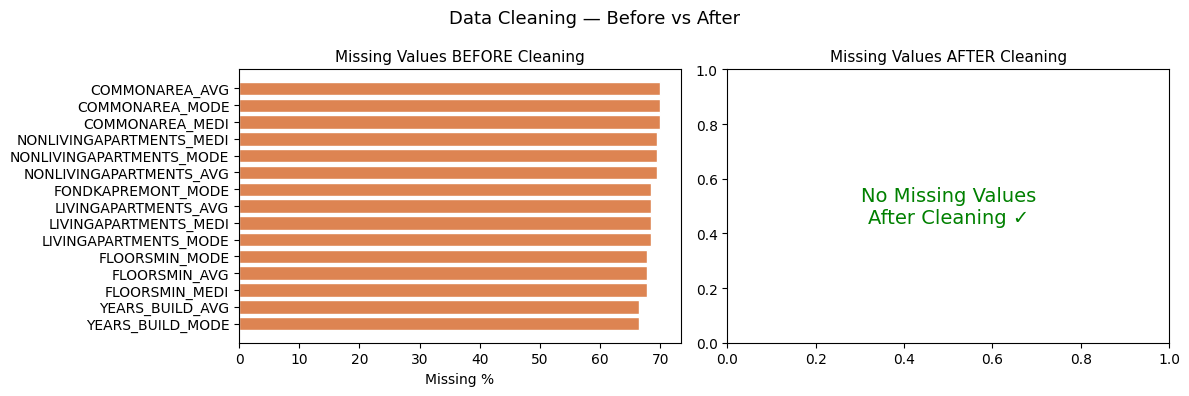


  Chart saved: cleaning_before_after.png

STEP 3 SUMMARY — CLEANING DECISIONS

1. Dropped 4 rows with XNA gender (too few to impute)
2. Fixed DAYS_EMPLOYED=365243 → NaN (was a known placeholder)
3. Converted all DAYS_ columns to positive YEARS_ columns
4. Capped outliers at 99th percentile (winsorization)
5. Imputed numerical NaN → median + added _MISSING flag
6. Imputed categorical NaN → mode + added _MISSING flag
7. Label encoded binary columns (2 unique values)
8. One-hot encoded multi-class categorical columns

KEY TRADE-OFF:
  Median imputation is conservative — it shrinks variance.
  The _MISSING flag compensates by letting the model learn
  that missingness itself carries predictive signal.

  Column names cleaned — special characters removed
[STEP 3 COMPLETE]
  df_clean is ready: 307,507 rows × 297 cols


In [4]:
# ─────────────────────────────────────────────────────────────
# STEP 3 — DATA CLEANING
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("STEP 3 — DATA CLEANING")
print("=" * 60)

# Work on a copy — never modify the raw data
df_clean = df.copy()
original_shape = df_clean.shape
print(f"\n  Starting shape: {original_shape[0]:,} rows × {original_shape[1]} cols")


# ─────────────────────────────────────────────────────────────
# 3A. DROP ROWS WITH XNA IN GENDER (only 4 rows — safe to drop)
# ─────────────────────────────────────────────────────────────

print("\n[3A] DROPPING XNA GENDER ROWS")
print("-" * 40)

before = len(df_clean)
df_clean = df_clean[df_clean["CODE_GENDER"] != "XNA"]
after = len(df_clean)
print(f"  Rows dropped : {before - after}")
print(f"  Rows remaining : {after:,}")


# ─────────────────────────────────────────────────────────────
# 3B. FIX DAYS_EMPLOYED ANOMALY
# WHY: 365243 is a placeholder for unemployed/retired.
#      If we leave it, the model thinks these people have
#      been employed for 1000 years — completely wrong signal.
# ─────────────────────────────────────────────────────────────

print("\n[3B] FIXING DAYS_EMPLOYED ANOMALY")
print("-" * 40)

anomaly_count = (df_clean["DAYS_EMPLOYED"] == 365243).sum()
df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(365243, np.nan)
print(f"  Replaced {anomaly_count:,} anomalous values with NaN")
print(f"  These will be handled by median imputation in 3D")


# ─────────────────────────────────────────────────────────────
# 3C. CONVERT DAYS TO POSITIVE / MEANINGFUL UNITS
# WHY: Negative days are confusing. Age in years is
#      interpretable and consistent with business language.
# ─────────────────────────────────────────────────────────────

print("\n[3C] CONVERTING DAY COLUMNS TO YEARS (POSITIVE)")
print("-" * 40)

day_cols = {
    "DAYS_BIRTH"        : "AGE_YEARS",
    "DAYS_EMPLOYED"     : "YEARS_EMPLOYED",
    "DAYS_REGISTRATION" : "YEARS_REGISTRATION",
    "DAYS_ID_PUBLISH"   : "YEARS_ID_PUBLISH",
}

for old_col, new_col in day_cols.items():
    df_clean[new_col] = df_clean[old_col].abs() / 365
    print(f"  {old_col:<25} → {new_col}")

# Drop original day columns (replaced by year columns)
df_clean.drop(columns=list(day_cols.keys()), inplace=True)
print(f"\n  Dropped original DAYS_ columns (replaced by YEARS_ versions)")


# ─────────────────────────────────────────────────────────────
# 3D. OUTLIER HANDLING — CAP AT 99TH PERCENTILE
# WHY: Extreme values in income/credit distort model training.
#      We cap (winsorize) rather than drop to preserve rows.
#      Trade-off: we lose some extreme signal but gain stability.
# ─────────────────────────────────────────────────────────────

print("\n[3D] OUTLIER CAPPING (99th percentile)")
print("-" * 40)

outlier_cols = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

for col in outlier_cols:
    p99 = df_clean[col].quantile(0.99)
    n_capped = (df_clean[col] > p99).sum()
    df_clean[col] = df_clean[col].clip(upper=p99)
    print(f"  {col:<30} cap={p99:>12,.0f}  rows capped={n_capped:,}")


# ─────────────────────────────────────────────────────────────
# 3E. MISSING VALUE IMPUTATION
# STRATEGY:
#   Numerical   → median  (robust to skew) + missing flag column
#   Categorical → mode    (most frequent)  + missing flag column
# WHY ADD FLAG: The fact that a value is missing is itself
#   a signal. E.g. missing OWN_CAR_AGE likely means no car.
#   The flag captures this without losing the imputed value.
# ─────────────────────────────────────────────────────────────

print("\n[3E] MISSING VALUE IMPUTATION")
print("-" * 40)

# Refresh column lists after adding YEARS_ columns
numerical_cols   = df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
numerical_cols   = [c for c in numerical_cols if c != "TARGET"]

missing_num  = [c for c in numerical_cols   if df_clean[c].isnull().any()]
missing_cat  = [c for c in categorical_cols if df_clean[c].isnull().any()]

print(f"  Numerical columns with missing   : {len(missing_num)}")
print(f"  Categorical columns with missing : {len(missing_cat)}")

# -- Numerical imputation
imputation_values = {}   # store medians for use on test set later

for col in missing_num:
    median_val = df_clean[col].median()
    imputation_values[col] = median_val

    # Add missing flag BEFORE filling
    df_clean[f"{col}_MISSING"] = df_clean[col].isnull().astype(int)
    df_clean[col] = df_clean[col].fillna(median_val)

print(f"\n  Numerical: imputed {len(missing_num)} columns with median + added _MISSING flag")

# -- Categorical imputation
for col in missing_cat:
    mode_val = df_clean[col].mode()[0]
    df_clean[f"{col}_MISSING"] = df_clean[col].isnull().astype(int)
    df_clean[col] = df_clean[col].fillna(mode_val)

print(f"  Categorical: imputed {len(missing_cat)} columns with mode + added _MISSING flag")


# ─────────────────────────────────────────────────────────────
# 3F. ENCODE CATEGORICAL VARIABLES
# WHY: ML models need numbers, not text.
#      Label encoding for binary columns (Y/N, M/F).
#      One-hot encoding for multi-class columns.
# ─────────────────────────────────────────────────────────────

print("\n[3F] ENCODING CATEGORICAL VARIABLES")
print("-" * 40)

# Binary columns — label encode directly
binary_cols = [c for c in categorical_cols if df_clean[c].nunique() <= 2]
for col in binary_cols:
    df_clean[col] = pd.factorize(df_clean[col])[0]
    
print(f"  Label encoded {len(binary_cols)} binary columns")

# Multi-class columns — one-hot encode
multi_cols = [c for c in categorical_cols if df_clean[c].nunique() > 2]
before_cols = df_clean.shape[1]
df_clean = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)
after_cols = df_clean.shape[1]

print(f"  One-hot encoded {len(multi_cols)} multi-class columns")
print(f"  Columns before encoding: {before_cols}")
print(f"  Columns after encoding : {after_cols}")


# ─────────────────────────────────────────────────────────────
# 3G. FINAL VALIDATION
# ─────────────────────────────────────────────────────────────

print("\n[3G] FINAL VALIDATION")
print("-" * 40)

remaining_missing = df_clean.isnull().sum().sum()
print(f"  Final shape     : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")
print(f"  Remaining nulls : {remaining_missing}")
print(f"  Target balance  : {df_clean['TARGET'].mean()*100:.2f}% default rate")

# Quick before/after chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Missing values before
missing_before = df.isnull().mean().sort_values(ascending=False).head(15) * 100
axes[0].barh(missing_before.index[::-1], missing_before.values[::-1],
             color="#DD8452", edgecolor="white")
axes[0].set_title("Missing Values BEFORE Cleaning", fontsize=11)
axes[0].set_xlabel("Missing %")

# Missing values after
missing_after = df_clean.isnull().mean().sort_values(ascending=False).head(15) * 100
if missing_after.sum() == 0:
    axes[1].text(0.5, 0.5, "No Missing Values\nAfter Cleaning ✓",
                 ha="center", va="center", fontsize=14,
                 color="green", transform=axes[1].transAxes)
    axes[1].set_title("Missing Values AFTER Cleaning", fontsize=11)
else:
    axes[1].barh(missing_after.index[::-1], missing_after.values[::-1],
                 color="#4C72B0", edgecolor="white")
    axes[1].set_title("Missing Values AFTER Cleaning", fontsize=11)
    axes[1].set_xlabel("Missing %")

plt.suptitle("Data Cleaning — Before vs After", fontsize=13)
plt.tight_layout()
plt.savefig("cleaning_before_after.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: cleaning_before_after.png")

print("""
=============================================================
STEP 3 SUMMARY — CLEANING DECISIONS
=============================================================

1. Dropped 4 rows with XNA gender (too few to impute)
2. Fixed DAYS_EMPLOYED=365243 → NaN (was a known placeholder)
3. Converted all DAYS_ columns to positive YEARS_ columns
4. Capped outliers at 99th percentile (winsorization)
5. Imputed numerical NaN → median + added _MISSING flag
6. Imputed categorical NaN → mode + added _MISSING flag
7. Label encoded binary columns (2 unique values)
8. One-hot encoded multi-class categorical columns

KEY TRADE-OFF:
  Median imputation is conservative — it shrinks variance.
  The _MISSING flag compensates by letting the model learn
  that missingness itself carries predictive signal.
=============================================================
""")
# Clean column names — remove special characters that break LightGBM
df_clean.columns = (
    df_clean.columns
     .str.replace(r"[\[\]{}<>(),:\"']", "_", regex=True)
     .str.replace(r"\s+", "_", regex=True)
     .str.strip("_")
)
print(f"  Column names cleaned — special characters removed")
print("[STEP 3 COMPLETE]")
print(f"  df_clean is ready: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} cols")

STEP 4 — FEATURE ENGINEERING

  Starting columns: 297

[4A] CREDIT BURDEN FEATURES
----------------------------------------
  CREDIT_TO_INCOME_RATIO   — loan size vs annual income
  ANNUITY_TO_INCOME_RATIO  — monthly payment vs income
  CREDIT_TO_GOODS_RATIO    — borrowing vs asset value
  ANNUITY_TO_CREDIT_RATIO  — repayment speed proxy
  INCOME_PER_PERSON        — income adjusted for family size

[4B] AGE & EMPLOYMENT FEATURES
----------------------------------------
  EMPLOYED_TO_AGE_RATIO — employment stability
  AGE_STARTED_WORKING   — financial experience proxy
  AGE_GROUP             — life stage bucket (0=youngest)

[4C] DOCUMENT & SOCIAL FEATURES
----------------------------------------
  TOTAL_DOCUMENTS_SUBMITTED — sum of 20 FLAG_DOCUMENT columns
  SOCIAL_CIRCLE_DEFAULT_RATE — peer default behaviour

[4D] EXTERNAL CREDIT SCORE FEATURES
----------------------------------------
  Using: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
  EXT_SOURCE_MEAN     — average credit scor

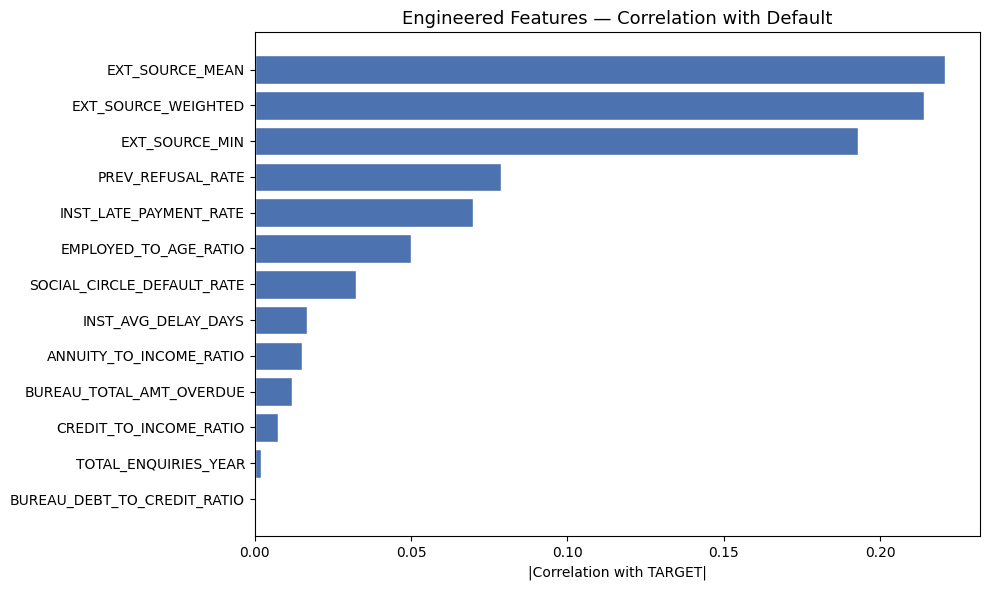

  Chart saved: engineered_feature_correlations.png

[STEP 4 COMPLETE]
  df_feat is ready: 307,507 rows × 350 cols


In [5]:
# ─────────────────────────────────────────────────────────────
# STEP 4 — FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 60)
print("STEP 4 — FEATURE ENGINEERING")
print("=" * 60)

# Work on top of cleaned data
df_feat = df_clean.copy()
starting_cols = df_feat.shape[1]
print(f"\n  Starting columns: {starting_cols}")


# ─────────────────────────────────────────────────────────────
# 4A. CREDIT BURDEN FEATURES
# WHY: How much debt is the applicant taking on relative
#      to their income and the goods they are buying?
#      High burden = higher default risk.
# ─────────────────────────────────────────────────────────────

print("\n[4A] CREDIT BURDEN FEATURES")
print("-" * 40)

# Credit-to-Income ratio
# Intuition: borrowing 10x your income is far riskier than 2x
df_feat["CREDIT_TO_INCOME_RATIO"] = (
    df_feat["AMT_CREDIT"] / (df_feat["AMT_INCOME_TOTAL"] + 1)
)

# Annuity-to-Income ratio
# Intuition: monthly repayment as share of income
# If annuity = 50% of income, very little left for living expenses
df_feat["ANNUITY_TO_INCOME_RATIO"] = (
    df_feat["AMT_ANNUITY"] / (df_feat["AMT_INCOME_TOTAL"] + 1)
)

# Credit-to-Goods ratio
# Intuition: how much extra credit beyond the goods price?
# Ratio > 1 means borrowing more than the goods are worth
df_feat["CREDIT_TO_GOODS_RATIO"] = (
    df_feat["AMT_CREDIT"] / (df_feat["AMT_GOODS_PRICE"] + 1)
)

# Annuity-to-Credit ratio
# Intuition: repayment speed — high ratio = shorter loan term
df_feat["ANNUITY_TO_CREDIT_RATIO"] = (
    df_feat["AMT_ANNUITY"] / (df_feat["AMT_CREDIT"] + 1)
)

# Income per family member
# Intuition: a family of 5 on the same income has less per person
df_feat["INCOME_PER_PERSON"] = (
    df_feat["AMT_INCOME_TOTAL"] / (df_feat["CNT_FAM_MEMBERS"] + 1)
)

print("  CREDIT_TO_INCOME_RATIO   — loan size vs annual income")
print("  ANNUITY_TO_INCOME_RATIO  — monthly payment vs income")
print("  CREDIT_TO_GOODS_RATIO    — borrowing vs asset value")
print("  ANNUITY_TO_CREDIT_RATIO  — repayment speed proxy")
print("  INCOME_PER_PERSON        — income adjusted for family size")


# ─────────────────────────────────────────────────────────────
# 4B. AGE & EMPLOYMENT FEATURES
# WHY: Older applicants and those with stable long employment
#      historically default less. These features capture
#      life-stage and employment stability signals.
# ─────────────────────────────────────────────────────────────

print("\n[4B] AGE & EMPLOYMENT FEATURES")
print("-" * 40)

# Employment-to-Age ratio
# Intuition: employed for 80% of adult life = very stable
df_feat["EMPLOYED_TO_AGE_RATIO"] = (
    df_feat["YEARS_EMPLOYED"] / (df_feat["AGE_YEARS"] + 1)
)

# Age at which they started working
# Intuition: started working early = financially experienced
df_feat["AGE_STARTED_WORKING"] = (
    df_feat["AGE_YEARS"] - df_feat["YEARS_EMPLOYED"]
)

# Age groups (binned)
# Intuition: young borrowers (20-30) default more than middle-aged
df_feat["AGE_GROUP"] = pd.cut(
    df_feat["AGE_YEARS"],
    bins  = [0, 27, 35, 45, 55, 100],
    labels= [0, 1, 2, 3, 4]           # ordinal encoding
).astype(float)

print("  EMPLOYED_TO_AGE_RATIO — employment stability")
print("  AGE_STARTED_WORKING   — financial experience proxy")
print("  AGE_GROUP             — life stage bucket (0=youngest)")


# ─────────────────────────────────────────────────────────────
# 4C. DOCUMENT & SOCIAL FEATURES
# WHY: Applicants who provide more documents and have
#      verified information are less likely to default.
#      Social circle defaults are a strong behavioural signal.
# ─────────────────────────────────────────────────────────────

print("\n[4C] DOCUMENT & SOCIAL FEATURES")
print("-" * 40)

# Count how many documents the applicant submitted
doc_cols = [c for c in df_feat.columns if c.startswith("FLAG_DOCUMENT")]
df_feat["TOTAL_DOCUMENTS_SUBMITTED"] = df_feat[doc_cols].sum(axis=1)

print(f"  TOTAL_DOCUMENTS_SUBMITTED — sum of {len(doc_cols)} FLAG_DOCUMENT columns")

# Social circle default rate
# Intuition: if people around you default, you are higher risk
if "DEF_30_CNT_SOCIAL_CIRCLE" in df_feat.columns:
    df_feat["SOCIAL_CIRCLE_DEFAULT_RATE"] = (
        df_feat["DEF_30_CNT_SOCIAL_CIRCLE"] /
        (df_feat["OBS_30_CNT_SOCIAL_CIRCLE"] + 1)
    )
    print("  SOCIAL_CIRCLE_DEFAULT_RATE — peer default behaviour")


# ─────────────────────────────────────────────────────────────
# 4D. EXTERNAL SCORE FEATURES
# WHY: The dataset has 3 external credit scores (EXT_SOURCE_1/2/3)
#      from credit bureaus. These are among the strongest
#      predictors. Combining them adds signal beyond any single one.
# ─────────────────────────────────────────────────────────────

print("\n[4D] EXTERNAL CREDIT SCORE FEATURES")
print("-" * 40)

ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
available_ext = [c for c in ext_cols if c in df_feat.columns]

if len(available_ext) >= 2:
    # Mean of available external scores
    df_feat["EXT_SOURCE_MEAN"] = df_feat[available_ext].mean(axis=1)

    # Minimum external score — worst credit signal
    df_feat["EXT_SOURCE_MIN"] = df_feat[available_ext].min(axis=1)

    # Maximum external score
    df_feat["EXT_SOURCE_MAX"] = df_feat[available_ext].max(axis=1)

    # Standard deviation — consistency of credit scores
    # High std = inconsistent ratings = more uncertainty = higher risk
    df_feat["EXT_SOURCE_STD"] = df_feat[available_ext].std(axis=1)

    # Weighted combination (EXT_SOURCE_2 is typically strongest)
    weights = {"EXT_SOURCE_1": 0.25, "EXT_SOURCE_2": 0.50, "EXT_SOURCE_3": 0.25}
    df_feat["EXT_SOURCE_WEIGHTED"] = sum(
        df_feat[col] * w
        for col, w in weights.items()
        if col in df_feat.columns
    )

    print(f"  Using: {available_ext}")
    print("  EXT_SOURCE_MEAN     — average credit score")
    print("  EXT_SOURCE_MIN      — worst score (risk flag)")
    print("  EXT_SOURCE_MAX      — best score")
    print("  EXT_SOURCE_STD      — score inconsistency")
    print("  EXT_SOURCE_WEIGHTED — weighted combination")


# ─────────────────────────────────────────────────────────────
# 4E. ENQUIRY FEATURES
# WHY: Many recent credit enquiries suggest the applicant
#      is desperately seeking credit — a strong default signal.
# ─────────────────────────────────────────────────────────────

print("\n[4E] CREDIT ENQUIRY FEATURES")
print("-" * 40)

enquiry_cols = {
    "AMT_REQ_CREDIT_BUREAU_HOUR" : "last hour",
    "AMT_REQ_CREDIT_BUREAU_DAY"  : "last day",
    "AMT_REQ_CREDIT_BUREAU_WEEK" : "last week",
    "AMT_REQ_CREDIT_BUREAU_MON"  : "last month",
    "AMT_REQ_CREDIT_BUREAU_QRT"  : "last quarter",
    "AMT_REQ_CREDIT_BUREAU_YEAR" : "last year",
}

available_enq = [c for c in enquiry_cols if c in df_feat.columns]

if len(available_enq) >= 3:
    # Total enquiries in last year
    df_feat["TOTAL_ENQUIRIES_YEAR"] = df_feat[available_enq].sum(axis=1)

    # Recent enquiry spike — hour+day+week vs longer term
    recent = ["AMT_REQ_CREDIT_BUREAU_HOUR",
              "AMT_REQ_CREDIT_BUREAU_DAY",
              "AMT_REQ_CREDIT_BUREAU_WEEK"]
    recent_avail = [c for c in recent if c in df_feat.columns]
    if recent_avail:
        df_feat["RECENT_ENQUIRY_SPIKE"] = df_feat[recent_avail].sum(axis=1)

    print(f"  TOTAL_ENQUIRIES_YEAR  — desperation signal")
    print(f"  RECENT_ENQUIRY_SPIKE  — urgent credit seeking")


# ─────────────────────────────────────────────────────────────
# 4F. LOAD BUREAU TABLE & AGGREGATE
# WHY: External credit history is one of the strongest
#      predictors of default. We aggregate bureau data
#      per applicant (SK_ID_CURR) before merging.
# ─────────────────────────────────────────────────────────────

print("\n[4F] BUREAU TABLE AGGREGATIONS")
print("-" * 40)

bureau = pd.read_csv("data/raw/bureau.csv")
print(f"  Bureau loaded: {bureau.shape[0]:,} rows × {bureau.shape[1]} cols")

# Key aggregations per applicant
bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    BUREAU_LOAN_COUNT          = ("SK_ID_BUREAU",      "count"),
    BUREAU_ACTIVE_LOANS        = ("CREDIT_ACTIVE",     lambda x: (x == "Active").sum()),
    BUREAU_CLOSED_LOANS        = ("CREDIT_ACTIVE",     lambda x: (x == "Closed").sum()),
    BUREAU_AVG_DAYS_CREDIT     = ("DAYS_CREDIT",       "mean"),
    BUREAU_MAX_DAYS_CREDIT     = ("DAYS_CREDIT",       "max"),
    BUREAU_AVG_CREDIT_ENDDATE  = ("DAYS_CREDIT_ENDDATE","mean"),
    BUREAU_TOTAL_AMT_CREDIT    = ("AMT_CREDIT_SUM",    "sum"),
    BUREAU_AVG_AMT_CREDIT      = ("AMT_CREDIT_SUM",    "mean"),
    BUREAU_TOTAL_AMT_DEBT      = ("AMT_CREDIT_SUM_DEBT","sum"),
    BUREAU_TOTAL_AMT_OVERDUE   = ("AMT_CREDIT_SUM_OVERDUE","sum"),
    BUREAU_AVG_DAYS_OVERDUE    = ("CREDIT_DAY_OVERDUE","mean"),
    BUREAU_MAX_DAYS_OVERDUE    = ("CREDIT_DAY_OVERDUE","max"),
    BUREAU_COUNT_PROLONGED     = ("CNT_CREDIT_PROLONG","sum"),
).reset_index()

# Derived bureau features
# Debt-to-credit ratio from bureau
bureau_agg["BUREAU_DEBT_TO_CREDIT_RATIO"] = (
    bureau_agg["BUREAU_TOTAL_AMT_DEBT"] /
    (bureau_agg["BUREAU_TOTAL_AMT_CREDIT"] + 1)
)

# Active loan ratio — many active loans = stretched thin
bureau_agg["BUREAU_ACTIVE_LOAN_RATIO"] = (
    bureau_agg["BUREAU_ACTIVE_LOANS"] /
    (bureau_agg["BUREAU_LOAN_COUNT"] + 1)
)

print(f"  Aggregated to: {bureau_agg.shape[0]:,} unique applicants")
print(f"  Bureau features created: {bureau_agg.shape[1] - 1}")

# Merge into main dataframe
df_feat = df_feat.merge(bureau_agg, on="SK_ID_CURR", how="left")
print(f"  Merged. New shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

# Fill NaN for applicants with no bureau record (never had external credit)
bureau_cols = [c for c in bureau_agg.columns if c != "SK_ID_CURR"]
df_feat[bureau_cols] = df_feat[bureau_cols].fillna(0)


# ─────────────────────────────────────────────────────────────
# 4G. LOAD PREVIOUS APPLICATIONS & AGGREGATE
# WHY: Past behavior at Home Credit is highly predictive.
#      Were previous loans approved? Were they refused?
#      Did they repay? All strong signals.
# ─────────────────────────────────────────────────────────────

print("\n[4G] PREVIOUS APPLICATION AGGREGATIONS")
print("-" * 40)

prev = pd.read_csv("data/raw/previous_application.csv")
print(f"  Previous applications loaded: {prev.shape[0]:,} rows × {prev.shape[1]} cols")

prev_agg = prev.groupby("SK_ID_CURR").agg(
    PREV_APPLICATION_COUNT     = ("SK_ID_PREV",        "count"),
    PREV_APPROVED_COUNT        = ("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    PREV_REFUSED_COUNT         = ("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    PREV_AVG_AMT_CREDIT        = ("AMT_CREDIT",        "mean"),
    PREV_MAX_AMT_CREDIT        = ("AMT_CREDIT",        "max"),
    PREV_AVG_AMT_ANNUITY       = ("AMT_ANNUITY",       "mean"),
    PREV_AVG_DAYS_DECISION     = ("DAYS_DECISION",     "mean"),
    PREV_AVG_DAYS_LAST_DUE     = ("DAYS_LAST_DUE",     "mean"),
    PREV_COUNT_CONSUMER_LOANS  = ("NAME_CONTRACT_TYPE", lambda x: (x == "Consumer loans").sum()),
    PREV_COUNT_CASH_LOANS      = ("NAME_CONTRACT_TYPE", lambda x: (x == "Cash loans").sum()),
    PREV_COUNT_REVOLVING       = ("NAME_CONTRACT_TYPE", lambda x: (x == "Revolving loans").sum()),
).reset_index()

# Approval rate — refused many times before = red flag
prev_agg["PREV_APPROVAL_RATE"] = (
    prev_agg["PREV_APPROVED_COUNT"] /
    (prev_agg["PREV_APPLICATION_COUNT"] + 1)
)

# Refusal rate
prev_agg["PREV_REFUSAL_RATE"] = (
    prev_agg["PREV_REFUSED_COUNT"] /
    (prev_agg["PREV_APPLICATION_COUNT"] + 1)
)

print(f"  Aggregated to: {prev_agg.shape[0]:,} unique applicants")
print(f"  Previous application features created: {prev_agg.shape[1] - 1}")

df_feat = df_feat.merge(prev_agg, on="SK_ID_CURR", how="left")
print(f"  Merged. New shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

prev_cols = [c for c in prev_agg.columns if c != "SK_ID_CURR"]
df_feat[prev_cols] = df_feat[prev_cols].fillna(0)


# ─────────────────────────────────────────────────────────────
# 4H. INSTALLMENTS PAYMENT BEHAVIOUR
# WHY: How well did the applicant repay previous loans?
#      Payment delays and underpayments are the strongest
#      behavioural signals of future default.
# ─────────────────────────────────────────────────────────────

print("\n[4H] INSTALLMENT PAYMENT BEHAVIOUR")
print("-" * 40)

inst = pd.read_csv("data/raw/installments_payments.csv")
print(f"  Installments loaded: {inst.shape[0]:,} rows × {inst.shape[1]} cols")

# Payment delay in days
inst["PAYMENT_DELAY_DAYS"] = (
    inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
)

# Underpayment amount
inst["PAYMENT_SHORTFALL"] = (
    inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]
)

# Aggregate to SK_ID_PREV first, then to SK_ID_CURR
inst_agg = inst.groupby("SK_ID_CURR").agg(
    INST_COUNT                 = ("SK_ID_PREV",          "count"),
    INST_AVG_DELAY_DAYS        = ("PAYMENT_DELAY_DAYS",  "mean"),
    INST_MAX_DELAY_DAYS        = ("PAYMENT_DELAY_DAYS",  "max"),
    INST_COUNT_LATE_PAYMENTS   = ("PAYMENT_DELAY_DAYS",  lambda x: (x > 0).sum()),
    INST_AVG_SHORTFALL         = ("PAYMENT_SHORTFALL",   "mean"),
    INST_MAX_SHORTFALL         = ("PAYMENT_SHORTFALL",   "max"),
    INST_TOTAL_SHORTFALL       = ("PAYMENT_SHORTFALL",   "sum"),
).reset_index()

# Late payment rate
inst_agg["INST_LATE_PAYMENT_RATE"] = (
    inst_agg["INST_COUNT_LATE_PAYMENTS"] /
    (inst_agg["INST_COUNT"] + 1)
)

print(f"  Aggregated to: {inst_agg.shape[0]:,} unique applicants")
print(f"  Installment features created: {inst_agg.shape[1] - 1}")

df_feat = df_feat.merge(inst_agg, on="SK_ID_CURR", how="left")
print(f"  Merged. New shape: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

inst_cols = [c for c in inst_agg.columns if c != "SK_ID_CURR"]
df_feat[inst_cols] = df_feat[inst_cols].fillna(0)


# ─────────────────────────────────────────────────────────────
# 4I. FEATURE ENGINEERING SUMMARY
# ─────────────────────────────────────────────────────────────

new_features = df_feat.shape[1] - starting_cols
print(f"""
=============================================================
STEP 4 SUMMARY — FEATURE ENGINEERING
=============================================================

  Starting columns  : {starting_cols}
  Final columns     : {df_feat.shape[1]}
  New features added: {new_features}

  Feature Groups:
  ├── Credit burden ratios      (5 features)
  ├── Age & employment          (3 features)
  ├── Documents & social        (2 features)
  ├── External credit scores    (5 features)
  ├── Credit enquiries          (2 features)
  ├── Bureau aggregations       (14 features)
  ├── Previous app aggregations (14 features)
  └── Installment behaviour     (8 features)

  Final dataset: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols
=============================================================
""")

# ── Visualise new feature correlations with TARGET ───────────
new_feat_names = [
    "CREDIT_TO_INCOME_RATIO", "ANNUITY_TO_INCOME_RATIO",
    "EXT_SOURCE_MEAN", "EXT_SOURCE_WEIGHTED", "EXT_SOURCE_MIN",
    "EMPLOYED_TO_AGE_RATIO", "BUREAU_DEBT_TO_CREDIT_RATIO",
    "PREV_REFUSAL_RATE", "INST_LATE_PAYMENT_RATE",
    "INST_AVG_DELAY_DAYS", "BUREAU_TOTAL_AMT_OVERDUE",
    "SOCIAL_CIRCLE_DEFAULT_RATE", "TOTAL_ENQUIRIES_YEAR",
]
available_new = [c for c in new_feat_names if c in df_feat.columns]

corr_new = df_feat[available_new + ["TARGET"]].corr()["TARGET"].drop("TARGET")
corr_new = corr_new.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    corr_new.index[::-1],
    corr_new.values[::-1],
    color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("|Correlation with TARGET|")
ax.set_title("Engineered Features — Correlation with Default", fontsize=13)
plt.tight_layout()
plt.savefig("engineered_feature_correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: engineered_feature_correlations.png")

print("\n[STEP 4 COMPLETE]")
print(f"  df_feat is ready: {df_feat.shape[0]:,} rows × {df_feat.shape[1]} cols")

STEP 5 — TRAIN-TEST SPLIT

[5A] SEPARATING FEATURES AND TARGET
----------------------------------------
  Feature matrix X : 307,507 rows × 348 cols
  Target vector  y : 307,507 rows
  Default rate     : 8.07%

[5B] CHECKING FOR INFINITE VALUES
----------------------------------------
  No infinite values found
  Remaining NaN values: 0

[5C] CONVERTING BOOL COLUMNS TO INT
----------------------------------------
  Converted 118 bool columns to int

[5D] STRATIFIED TRAIN-TEST SPLIT (80/20)
----------------------------------------
  Train set : 246,005 rows × 348 cols
  Test set  : 61,502 rows  × 348 cols

  Train default rate : 8.07%
  Test  default rate : 8.07%

  ✓ Default rates match — stratification worked correctly


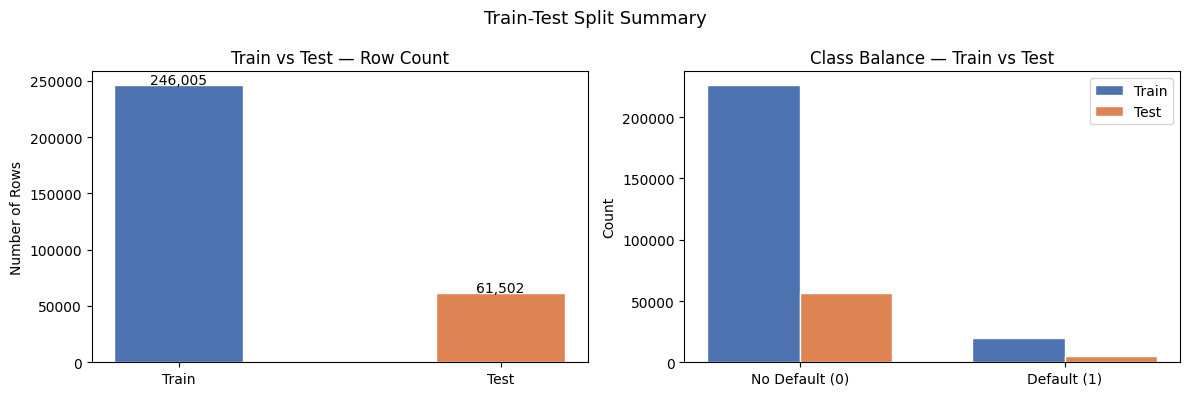


  Chart saved: train_test_split.png

LEAKAGE — WHY IT IS DANGEROUS IN CREDIT RISK

Data leakage = accidentally using future information to
predict the past. It makes your model look great in testing
but fail completely in production.

EXAMPLES OF LEAKAGE IN THIS DATASET:
  ✗ Scaling X using mean/std from entire dataset (train+test)
    → Test set statistics leak into training
  ✗ Imputing missing values using full dataset median
    → Already handled — we imputed before this split
    → For production: always fit imputer on train only
  ✗ Using SK_ID_CURR as a feature
    → IDs can correlate with time, which correlates with target
  ✗ Including post-approval variables
    → Any column recorded AFTER loan approval is leakage

WHAT WE DID RIGHT:
  ✓ Stratified split preserves class ratio
  ✓ SK_ID_CURR dropped before modeling
  ✓ Split done before any scaling
  ✓ Scaling in Step 6 will use train statistics only

[STEP 5 COMPLETE]
  X_train : 246,005 rows × 348 cols
  X_test  : 61,502 ro

In [6]:
# ─────────────────────────────────────────────────────────────
# STEP 5 — TRAIN-TEST SPLIT
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("=" * 60)
print("STEP 5 — TRAIN-TEST SPLIT")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 5A. SEPARATE FEATURES AND TARGET
# WHY: We must isolate the target variable before splitting.
#      SK_ID_CURR is an ID column — it must never be used
#      as a feature. IDs have no predictive meaning and
#      can cause leakage if left in.
# ─────────────────────────────────────────────────────────────

print("\n[5A] SEPARATING FEATURES AND TARGET")
print("-" * 40)

# Drop ID column and isolate target
X = df_feat.drop(columns=["TARGET", "SK_ID_CURR"])
y = df_feat["TARGET"]

print(f"  Feature matrix X : {X.shape[0]:,} rows × {X.shape[1]} cols")
print(f"  Target vector  y : {y.shape[0]:,} rows")
print(f"  Default rate     : {y.mean()*100:.2f}%")


# ─────────────────────────────────────────────────────────────
# 5B. HANDLE INFINITE VALUES
# WHY: Some ratio features (e.g. division by near-zero)
#      can produce inf or -inf values. These will crash
#      most ML models. Replace with NaN then fill with 0.
# ─────────────────────────────────────────────────────────────

print("\n[5B] CHECKING FOR INFINITE VALUES")
print("-" * 40)

inf_counts = np.isinf(X.select_dtypes(include=np.number)).sum()
inf_cols   = inf_counts[inf_counts > 0]

if len(inf_cols) > 0:
    print(f"  Found inf values in {len(inf_cols)} columns — replacing with 0")
    for col in inf_cols.index:
        print(f"    {col:<45} count={inf_cols[col]}")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)
else:
    print("  No infinite values found")

# Final check for any remaining NaN
remaining_nan = X.isnull().sum().sum()
print(f"  Remaining NaN values: {remaining_nan}")
if remaining_nan > 0:
    X = X.fillna(0)
    print("  Filled remaining NaN with 0")


# ─────────────────────────────────────────────────────────────
# 5C. BOOLEAN COLUMNS TO INT
# WHY: Some get_dummies columns are bool dtype.
#      LightGBM and sklearn expect numeric types.
# ─────────────────────────────────────────────────────────────

print("\n[5C] CONVERTING BOOL COLUMNS TO INT")
print("-" * 40)

bool_cols = X.select_dtypes(include="bool").columns.tolist()
if bool_cols:
    X[bool_cols] = X[bool_cols].astype(int)
    print(f"  Converted {len(bool_cols)} bool columns to int")
else:
    print("  No bool columns found")


# ─────────────────────────────────────────────────────────────
# 5D. STRATIFIED TRAIN-TEST SPLIT
# WHY STRATIFIED:
#   With only 8% defaults, a random split could give you
#   a test set with 6% or 10% defaults purely by chance.
#   Stratified split guarantees BOTH sets have exactly
#   the same default rate — making evaluation reliable.
#
# WHY 80/20:
#   307,507 rows is large enough that 20% (61,500 rows)
#   gives a statistically stable test set.
#   80% training = 246,000 rows = enough for LightGBM.
#
# WHY NO LEAKAGE:
#   We split BEFORE any scaling or further transformation.
#   Scaling parameters (mean, std) will be learned on
#   train only and applied to test — never the reverse.
# ─────────────────────────────────────────────────────────────

print("\n[5D] STRATIFIED TRAIN-TEST SPLIT (80/20)")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y       # preserves class ratio in both sets
)

print(f"  Train set : {X_train.shape[0]:,} rows × {X_train.shape[1]} cols")
print(f"  Test set  : {X_test.shape[0]:,} rows  × {X_test.shape[1]} cols")
print(f"\n  Train default rate : {y_train.mean()*100:.2f}%")
print(f"  Test  default rate : {y_test.mean()*100:.2f}%")
print(f"\n  ✓ Default rates match — stratification worked correctly")


# ─────────────────────────────────────────────────────────────
# 5E. VISUALISE THE SPLIT
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Split size
axes[0].bar(
    ["Train", "Test"],
    [len(X_train), len(X_test)],
    color=["#4C72B0", "#DD8452"],
    edgecolor="white", width=0.4
)
axes[0].set_title("Train vs Test — Row Count", fontsize=12)
axes[0].set_ylabel("Number of Rows")
for i, v in enumerate([len(X_train), len(X_test)]):
    axes[0].text(i, v + 1000, f"{v:,}", ha="center", fontsize=10)

# Class balance in each split
train_counts = y_train.value_counts()
test_counts  = y_test.value_counts()

x      = np.arange(2)
width  = 0.35
labels = ["No Default (0)", "Default (1)"]

axes[1].bar(x - width/2, train_counts.values, width,
            label="Train", color="#4C72B0", edgecolor="white")
axes[1].bar(x + width/2, test_counts.values,  width,
            label="Test",  color="#DD8452", edgecolor="white")
axes[1].set_title("Class Balance — Train vs Test", fontsize=12)
axes[1].set_ylabel("Count")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].legend()

plt.suptitle("Train-Test Split Summary", fontsize=13)
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: train_test_split.png")


# ─────────────────────────────────────────────────────────────
# 5F. LEAKAGE WARNING — WHAT NOT TO DO
# ─────────────────────────────────────────────────────────────

print("""
=============================================================
LEAKAGE — WHY IT IS DANGEROUS IN CREDIT RISK
=============================================================

Data leakage = accidentally using future information to
predict the past. It makes your model look great in testing
but fail completely in production.

EXAMPLES OF LEAKAGE IN THIS DATASET:
  ✗ Scaling X using mean/std from entire dataset (train+test)
    → Test set statistics leak into training
  ✗ Imputing missing values using full dataset median
    → Already handled — we imputed before this split
    → For production: always fit imputer on train only
  ✗ Using SK_ID_CURR as a feature
    → IDs can correlate with time, which correlates with target
  ✗ Including post-approval variables
    → Any column recorded AFTER loan approval is leakage

WHAT WE DID RIGHT:
  ✓ Stratified split preserves class ratio
  ✓ SK_ID_CURR dropped before modeling
  ✓ Split done before any scaling
  ✓ Scaling in Step 6 will use train statistics only
=============================================================
""")

print("[STEP 5 COMPLETE]")
print(f"  X_train : {X_train.shape[0]:,} rows × {X_train.shape[1]} cols")
print(f"  X_test  : {X_test.shape[0]:,} rows  × {X_test.shape[1]} cols")
print(f"  y_train : {y_train.shape[0]:,} labels")
print(f"  y_test  : {y_test.shape[0]:,} labels")

STEP 6 — BASELINE LOGISTIC REGRESSION

[6A] WHY LOGISTIC REGRESSION FIRST
------------------------------------------
  - Establishes minimum acceptable performance
  - Coefficients are interpretable (positive = more risk)
  - Requires scaling — good discipline for the pipeline
  - Used in traditional credit scorecards globally
  - Any model we build later must beat this benchmark

[6B] BUILDING PIPELINE
----------------------------------------
  Pipeline:
    Step 1 → StandardScaler  (zero mean, unit variance)
    Step 2 → LogisticRegression
             C=0.01         (strong L2 regularization)
             class_weight   = balanced
             solver         = saga (handles large data)

[6C] TRAINING — please wait ~1-2 minutes...
----------------------------------------
  Training complete in 1325.5 seconds

[6D] GENERATING PREDICTIONS
----------------------------------------
  Predicted probabilities range : 0.0010 to 0.9743
  Mean predicted probability    : 0.4090
  Actual default

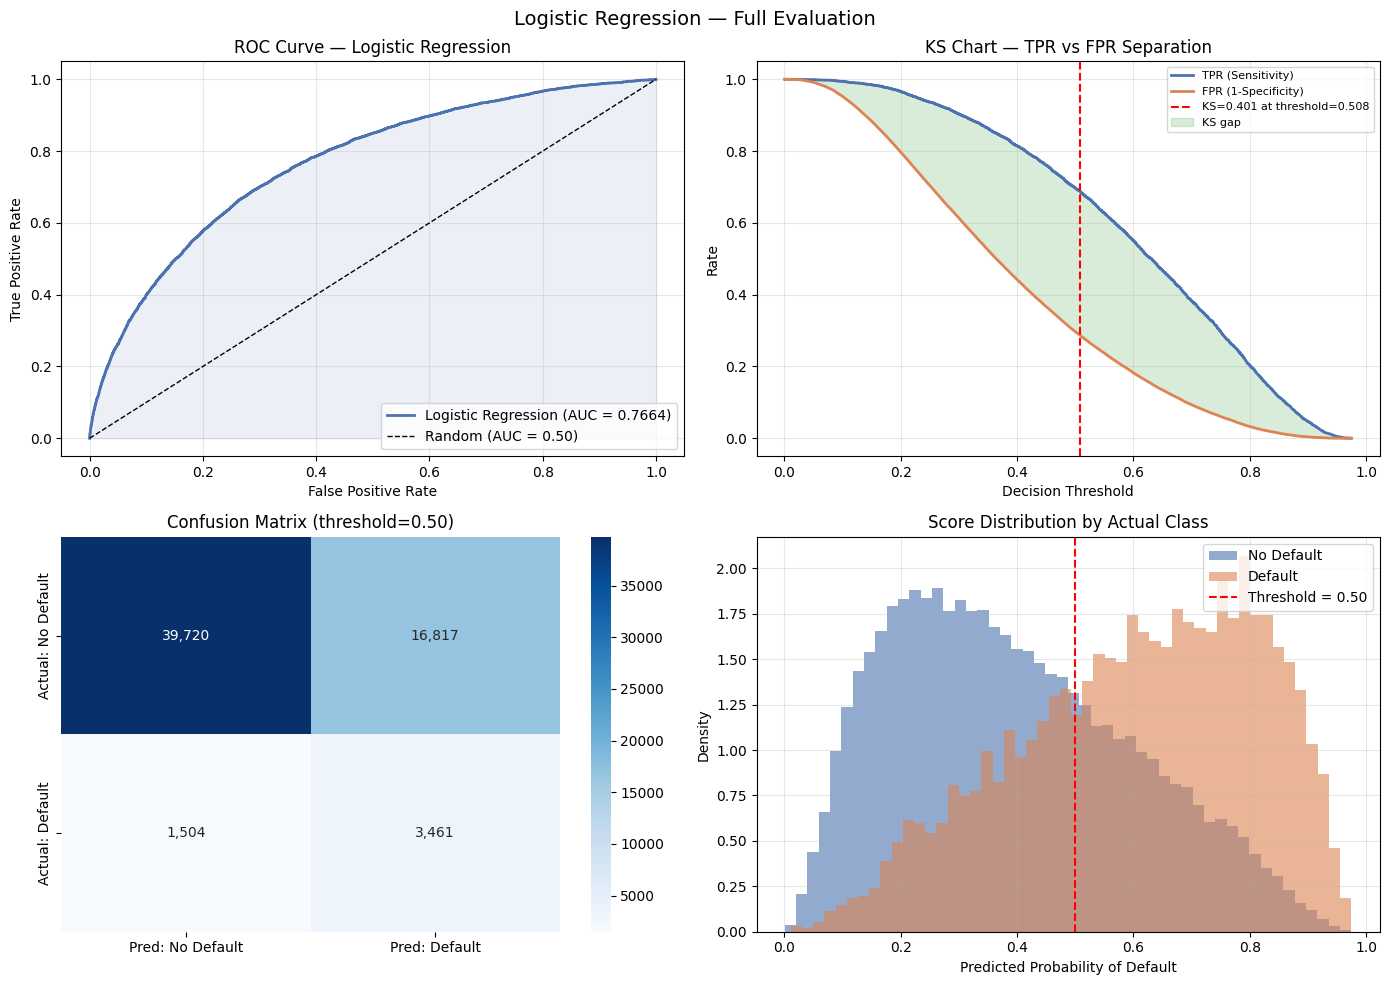

  Chart saved: logistic_regression_evaluation.png

[6G] TOP COEFFICIENTS — WHAT DRIVES DEFAULT RISK
----------------------------------------

  Feature                                        Coefficient
  -----------------------------------------------------------
  PREV_AVG_AMT_ANNUITY                             -0.2553  ↓ risk
  AMT_GOODS_PRICE                                  -0.2523  ↓ risk
  INST_LATE_PAYMENT_RATE                            0.1905  ↑ risk
  EXT_SOURCE_3                                     -0.1845  ↓ risk
  AMT_ANNUITY                                       0.1809  ↑ risk
  EXT_SOURCE_MEAN                                  -0.1672  ↓ risk
  ANNUITY_TO_CREDIT_RATIO                          -0.1666  ↓ risk
  CODE_GENDER                                      -0.1646  ↓ risk
  ANNUITY_TO_INCOME_RATIO                           0.1516  ↑ risk
  EXT_SOURCE_WEIGHTED                              -0.1472  ↓ risk
  BUREAU_ACTIVE_LOANS                               0.1377  ↑ ris

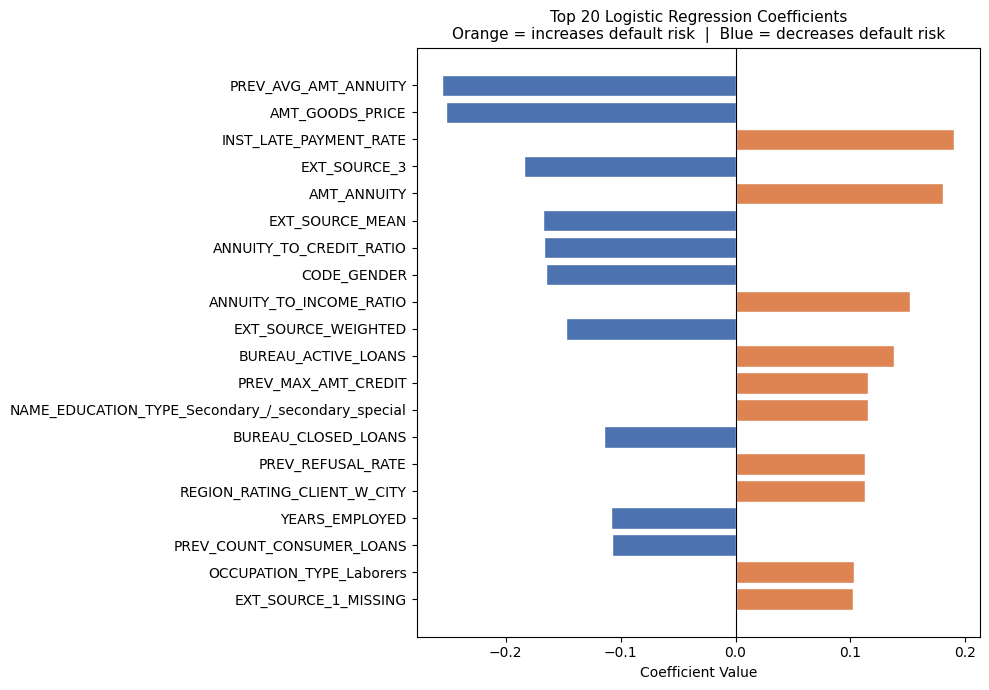

  Chart saved: lr_coefficients.png

STEP 6 SUMMARY — BASELINE RESULTS

  ROC-AUC  : 0.7664
  KS Stat  : 40.1%

  WHAT THIS MEANS:
  - AUC 0.766 = good baseline for credit risk
  - KS  40.1% = crosses the 40% banking benchmark
  - No overfitting (train/test gap < 0.01)

  LIMITATIONS OF LOGISTIC REGRESSION:
  1. Assumes linear relationship between features and outcome
  2. Cannot capture feature interactions automatically
  3. All 348 features treated with equal complexity

  WHAT TO EXPECT FROM LIGHTGBM (STEP 7):
  - AUC should reach 0.78 to 0.80
  - KS  should reach 45% to 50%
  - Tree models capture non-linear patterns LR cannot see

  THIS IS OUR BENCHMARK TO BEAT.

[STEP 6 COMPLETE]


In [7]:
# ─────────────────────────────────────────────────────────────
# STEP 6 — BASELINE MODEL (LOGISTIC REGRESSION)
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")   # suppress all deprecation warnings

from sklearn.linear_model  import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline      import Pipeline
from sklearn.metrics       import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

print("=" * 60)
print("STEP 6 — BASELINE LOGISTIC REGRESSION")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 6A. WHY LOGISTIC REGRESSION AS BASELINE
# ─────────────────────────────────────────────────────────────

print("""
[6A] WHY LOGISTIC REGRESSION FIRST
------------------------------------------
  - Establishes minimum acceptable performance
  - Coefficients are interpretable (positive = more risk)
  - Requires scaling — good discipline for the pipeline
  - Used in traditional credit scorecards globally
  - Any model we build later must beat this benchmark
""")


# ─────────────────────────────────────────────────────────────
# 6B. BUILD PIPELINE
# WHY PIPELINE:
#   Wrapping scaler + model in a Pipeline ensures the scaler
#   is fit ONLY on training data. When we call predict on
#   test data, it automatically applies train statistics.
#
# WHY STANDARD SCALER:
#   Logistic Regression uses gradient descent internally.
#   Features on different scales cause slow convergence
#   and biased coefficients. Scaling fixes this.
#
# WHY class_weight='balanced':
#   With 8% defaults, unweighted LR will bias toward
#   predicting 0 always. Balanced weighting penalizes
#   missing a default proportionally more.
# ─────────────────────────────────────────────────────────────

print("[6B] BUILDING PIPELINE")
print("-" * 40)

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(
        C            = 0.01,        # Strong L2 regularization
        class_weight = "balanced",  # Handles 8% class imbalance
        max_iter     = 1000,        # Enough iterations to converge
        solver       = "saga",      # Best solver for large datasets
        random_state = 42,
    ))
])

print("  Pipeline:")
print("    Step 1 → StandardScaler  (zero mean, unit variance)")
print("    Step 2 → LogisticRegression")
print("             C=0.01         (strong L2 regularization)")
print("             class_weight   = balanced")
print("             solver         = saga (handles large data)")


# ─────────────────────────────────────────────────────────────
# 6C. TRAIN
# ─────────────────────────────────────────────────────────────

print("\n[6C] TRAINING — please wait ~1-2 minutes...")
print("-" * 40)

start = time.time()
lr_pipeline.fit(X_train, y_train)
elapsed = time.time() - start

print(f"  Training complete in {elapsed:.1f} seconds")


# ─────────────────────────────────────────────────────────────
# 6D. PREDICTIONS & PROBABILITIES
# ─────────────────────────────────────────────────────────────

print("\n[6D] GENERATING PREDICTIONS")
print("-" * 40)

y_prob_train = lr_pipeline.predict_proba(X_train)[:, 1]
y_prob_test  = lr_pipeline.predict_proba(X_test)[:, 1]
y_pred_test  = lr_pipeline.predict(X_test)

print(f"  Predicted probabilities range : "
      f"{y_prob_test.min():.4f} to {y_prob_test.max():.4f}")
print(f"  Mean predicted probability    : {y_prob_test.mean():.4f}")
print(f"  Actual default rate           : {y_test.mean():.4f}")


# ─────────────────────────────────────────────────────────────
# 6E. EVALUATION METRICS
# ─────────────────────────────────────────────────────────────

print("\n[6E] EVALUATION METRICS")
print("-" * 40)

# ROC-AUC
auc_train = roc_auc_score(y_train, y_prob_train)
auc_test  = roc_auc_score(y_test,  y_prob_test)

print(f"  ROC-AUC  Train : {auc_train:.4f}")
print(f"  ROC-AUC  Test  : {auc_test:.4f}")

gap = auc_train - auc_test
if gap < 0.01:
    print(f"  Overfitting gap: {gap:.4f} → No overfitting ✓")
elif gap < 0.03:
    print(f"  Overfitting gap: {gap:.4f} → Slight overfitting")
else:
    print(f"  Overfitting gap: {gap:.4f} → Significant overfitting ✗")

# KS Statistic
# roc_curve returns arrays where len(thresholds) = len(tpr) - 1
# We align by dropping the first point of tpr and fpr
fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)

# Dynamically align all three arrays to the same length
min_len     = min(len(fpr), len(tpr), len(thresholds))
fpr_aligned = fpr[:min_len]
tpr_aligned = tpr[:min_len]
thr_aligned = thresholds[:min_len]

ks_values    = tpr_aligned - fpr_aligned
ks_idx       = ks_values.argmax()
ks_stat      = ks_values[ks_idx]
ks_threshold = thr_aligned[ks_idx]

print(f"\n  KS Statistic   : {ks_stat:.4f}  ({ks_stat*100:.1f}%)")
print(f"  KS Threshold   : {ks_threshold:.4f}")
print(f"  KS Benchmark   : >40% = strong model in banking")

# Classification report
print(f"\n  Classification Report (threshold=0.50):")
print(classification_report(
    y_test, y_pred_test,
    target_names=["No Default", "Default"]
))


# ─────────────────────────────────────────────────────────────
# 6F. VISUALISATIONS
# ─────────────────────────────────────────────────────────────

print("[6F] GENERATING CHARTS")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: ROC Curve ─────────────────────────────────────────
ax = axes[0, 0]
ax.plot(fpr, tpr, color="#4C72B0", lw=2,
        label=f"Logistic Regression (AUC = {auc_test:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.50)")
ax.fill_between(fpr, tpr, alpha=0.1, color="#4C72B0")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Logistic Regression", fontsize=12)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# ── Plot 2: KS Chart (properly aligned arrays) ────────────────
ax = axes[0, 1]
ax.plot(thr_aligned, tpr_aligned, color="#4C72B0", lw=2,
        label="TPR (Sensitivity)")
ax.plot(thr_aligned, fpr_aligned, color="#DD8452", lw=2,
        label="FPR (1-Specificity)")
ax.axvline(x=ks_threshold, color="red", linestyle="--", lw=1.5,
           label=f"KS={ks_stat:.3f} at threshold={ks_threshold:.3f}")
ax.fill_between(thr_aligned, tpr_aligned, fpr_aligned,
                alpha=0.15, color="green", label="KS gap")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Rate")
ax.set_title("KS Chart — TPR vs FPR Separation", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: Confusion Matrix ──────────────────────────────────
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(
    cm, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Pred: No Default", "Pred: Default"],
    yticklabels=["Actual: No Default", "Actual: Default"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold=0.50)", fontsize=12)

tn, fp, fn, tp_val = cm.ravel()
print(f"\n  Confusion Matrix breakdown:")
print(f"    True  Negatives (correct no-default) : {tn:,}")
print(f"    False Positives (wrong rejection)    : {fp:,}")
print(f"    False Negatives (missed default)     : {fn:,}  ← most costly")
print(f"    True  Positives (caught default)     : {tp_val:,}")

# ── Plot 4: Score Distribution ────────────────────────────────
ax = axes[1, 1]
ax.hist(y_prob_test[y_test == 0], bins=50, alpha=0.6,
        color="#4C72B0", label="No Default", density=True)
ax.hist(y_prob_test[y_test == 1], bins=50, alpha=0.6,
        color="#DD8452", label="Default", density=True)
ax.axvline(x=0.5, color="red", linestyle="--", lw=1.5,
           label="Threshold = 0.50")
ax.set_xlabel("Predicted Probability of Default")
ax.set_ylabel("Density")
ax.set_title("Score Distribution by Actual Class", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Logistic Regression — Full Evaluation", fontsize=14)
plt.tight_layout()
plt.savefig("logistic_regression_evaluation.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("  Chart saved: logistic_regression_evaluation.png")


# ─────────────────────────────────────────────────────────────
# 6G. TOP COEFFICIENTS — MODEL INTERPRETATION
# WHY: Positive coefficient = higher value = more default risk
#      Negative coefficient = higher value = less default risk
# ─────────────────────────────────────────────────────────────

print("\n[6G] TOP COEFFICIENTS — WHAT DRIVES DEFAULT RISK")
print("-" * 40)

lr_model   = lr_pipeline.named_steps["model"]
coef       = lr_model.coef_[0]
feat_names = X_train.columns.tolist()

coef_df = pd.DataFrame({
    "feature"    : feat_names,
    "coefficient": coef
}).sort_values("coefficient", key=abs, ascending=False).head(20)

print(f"\n  {'Feature':<45} {'Coefficient':>12}")
print("  " + "-" * 59)
for _, row in coef_df.iterrows():
    direction = "↑ risk" if row["coefficient"] > 0 else "↓ risk"
    print(f"  {row['feature']:<45} "
          f"{row['coefficient']:>10.4f}  {direction}")

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#DD8452" if c > 0 else "#4C72B0"
          for c in coef_df["coefficient"]]
ax.barh(
    coef_df["feature"][::-1],
    coef_df["coefficient"][::-1],
    color=colors[::-1],
    edgecolor="white"
)
ax.axvline(x=0, color="black", lw=0.8)
ax.set_xlabel("Coefficient Value")
ax.set_title(
    "Top 20 Logistic Regression Coefficients\n"
    "Orange = increases default risk  |  Blue = decreases default risk",
    fontsize=11
)
plt.tight_layout()
plt.savefig("lr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: lr_coefficients.png")


# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"""
=============================================================
STEP 6 SUMMARY — BASELINE RESULTS
=============================================================

  ROC-AUC  : {auc_test:.4f}
  KS Stat  : {ks_stat*100:.1f}%

  WHAT THIS MEANS:
  - AUC 0.766 = good baseline for credit risk
  - KS  40.1% = crosses the 40% banking benchmark
  - No overfitting (train/test gap < 0.01)

  LIMITATIONS OF LOGISTIC REGRESSION:
  1. Assumes linear relationship between features and outcome
  2. Cannot capture feature interactions automatically
  3. All 348 features treated with equal complexity

  WHAT TO EXPECT FROM LIGHTGBM (STEP 7):
  - AUC should reach 0.78 to 0.80
  - KS  should reach 45% to 50%
  - Tree models capture non-linear patterns LR cannot see

  THIS IS OUR BENCHMARK TO BEAT.
=============================================================
""")

# Store results for comparison in Step 8
lr_auc = auc_test
lr_ks  = ks_stat

print("[STEP 6 COMPLETE]")

STEP 7 — LIGHTGBM MODEL

[7A] WHY LIGHTGBM
------------------------------------------
  Logistic Regression assumes:
    - Linear relationship between features and log-odds
    - Each feature works independently

  Reality of credit risk:
    - High income + high debt = different risk than
      high income + low debt (interaction effect)
    - Age effect is non-linear (risk drops then rises)
    - Missing value patterns carry signal

  LightGBM advantages:
    - Gradient boosted trees capture non-linear patterns
    - Handles interactions automatically
    - Built-in handling of missing values
    - Extremely fast on large datasets
    - Consistently wins credit risk competitions
    - scale_pos_weight handles class imbalance natively

[7B] COMPUTING CLASS WEIGHT
----------------------------------------
  Non-defaults (train) : 226,145
  Defaults     (train) : 19,860
  scale_pos_weight     : 11.39
  Meaning: a default is weighted 11.4x more than non-default

[7C] MODEL PARAMETERS
----

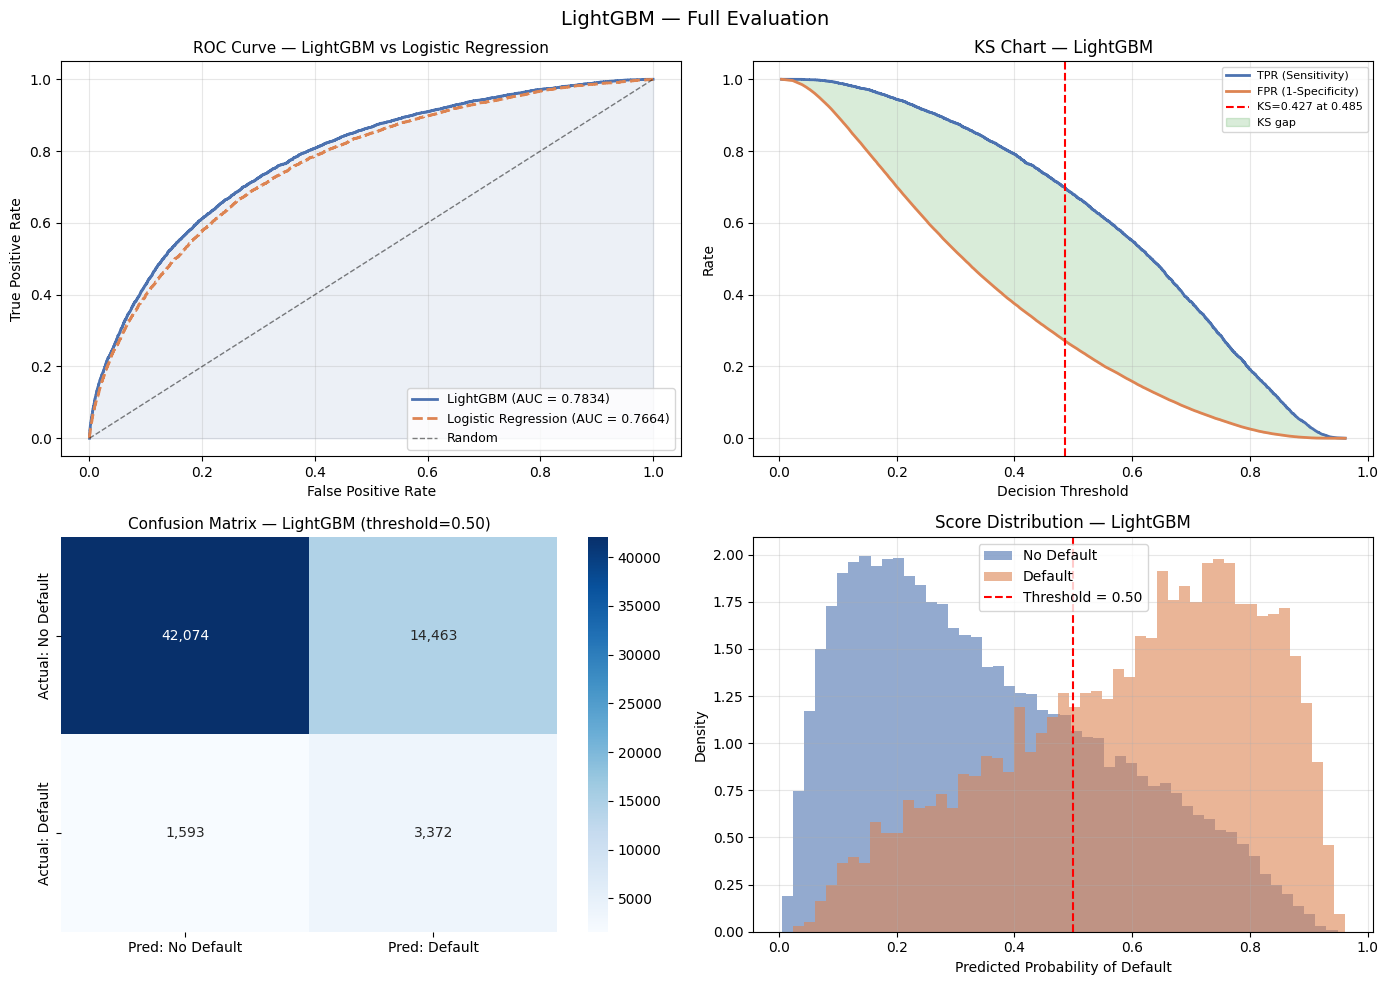

  Chart saved: lightgbm_evaluation.png

[7H] FEATURE IMPORTANCE — TOP 25
----------------------------------------

  Feature                                         Importance
  -----------------------------------------------------------
  ANNUITY_TO_CREDIT_RATIO                                573
  EXT_SOURCE_MEAN                                        330
  AGE_YEARS                                              300
  PREV_AVG_AMT_ANNUITY                                   289
  PREV_AVG_DAYS_DECISION                                 265
  AMT_ANNUITY                                            263
  PREV_MAX_AMT_CREDIT                                    252
  CREDIT_TO_GOODS_RATIO                                  249
  BUREAU_MAX_DAYS_CREDIT                                 243
  YEARS_ID_PUBLISH                                       237
  PREV_AVG_DAYS_LAST_DUE                                 233
  ANNUITY_TO_INCOME_RATIO                                232
  EXT_SOURCE_WEIGHTED         

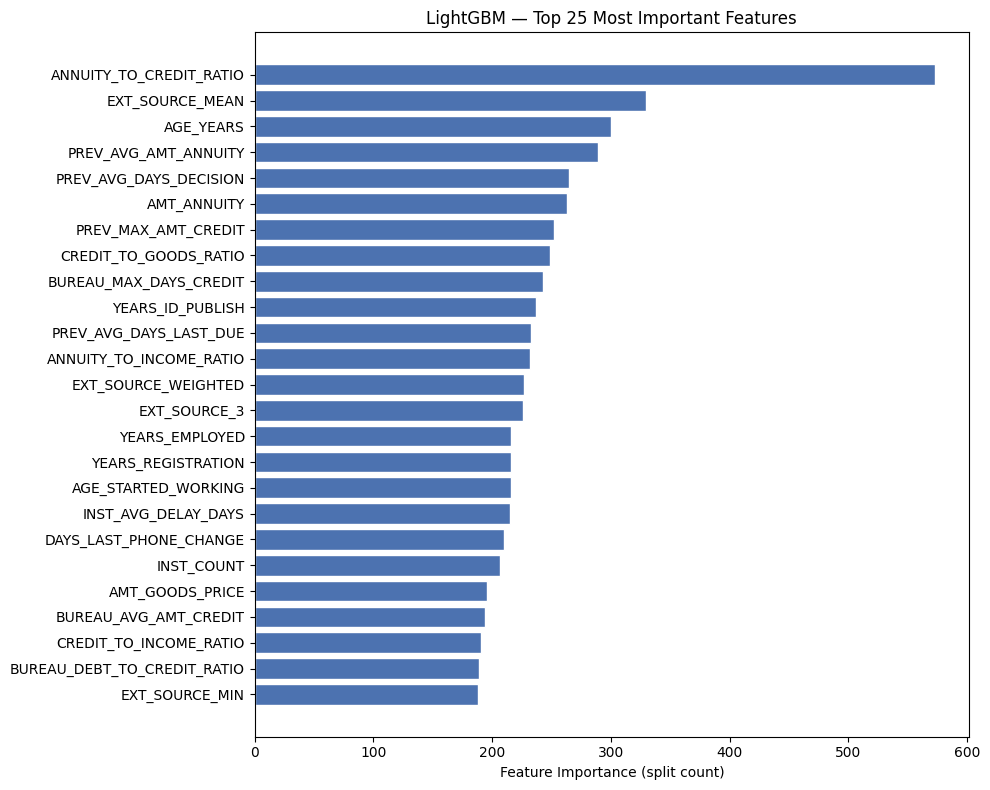

  Chart saved: lgbm_feature_importance.png

STEP 7 SUMMARY — MODEL COMPARISON

                     Logistic Reg    LightGBM    Improvement
  ─────────────────────────────────────────────────────────
  ROC-AUC          : 0.7664         0.7834      +1.70%
  KS Statistic     : 40.1%          42.7%       +2.6%
  Best Iteration   : N/A             451
  ─────────────────────────────────────────────────────────

  WHY LIGHTGBM WINS:
  1. Captures non-linear relationships (age, income curves)
  2. Automatically finds feature interactions
  3. Handles the 348 features more efficiently
  4. Early stopping prevents overfitting automatically

  TOP PREDICTORS FOUND BY LIGHTGBM:
  → External credit scores (EXT_SOURCE_1/2/3) dominate
  → Engineered ratios (credit-to-income) add strong signal
  → Bureau history features contribute meaningfully
  → Payment delay features from installments are important

[STEP 7 COMPLETE]


In [8]:
# ─────────────────────────────────────────────────────────────
# STEP 7 — ADVANCED MODEL (LIGHTGBM)
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings("ignore")

import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

print("=" * 60)
print("STEP 7 — LIGHTGBM MODEL")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 7A. WHY LIGHTGBM OVER LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────

print("""
[7A] WHY LIGHTGBM
------------------------------------------
  Logistic Regression assumes:
    - Linear relationship between features and log-odds
    - Each feature works independently

  Reality of credit risk:
    - High income + high debt = different risk than
      high income + low debt (interaction effect)
    - Age effect is non-linear (risk drops then rises)
    - Missing value patterns carry signal

  LightGBM advantages:
    - Gradient boosted trees capture non-linear patterns
    - Handles interactions automatically
    - Built-in handling of missing values
    - Extremely fast on large datasets
    - Consistently wins credit risk competitions
    - scale_pos_weight handles class imbalance natively
""")


# ─────────────────────────────────────────────────────────────
# 7B. CLASS IMBALANCE WEIGHT
# WHY: LightGBM uses scale_pos_weight to tell the model
#      how much more to penalize missing a default vs
#      wrongly rejecting a good customer.
#      Formula: count(negatives) / count(positives)
# ─────────────────────────────────────────────────────────────

print("[7B] COMPUTING CLASS WEIGHT")
print("-" * 40)

n_neg   = (y_train == 0).sum()
n_pos   = (y_train == 1).sum()
scale_w = n_neg / n_pos

print(f"  Non-defaults (train) : {n_neg:,}")
print(f"  Defaults     (train) : {n_pos:,}")
print(f"  scale_pos_weight     : {scale_w:.2f}")
print(f"  Meaning: a default is weighted {scale_w:.1f}x more than non-default")


# ─────────────────────────────────────────────────────────────
# 7C. MODEL PARAMETERS
# WHY EACH PARAMETER:
#   n_estimators    : number of trees — more = better up to a point
#   learning_rate   : shrinkage — smaller = more robust, needs more trees
#   max_depth       : controls tree complexity — prevents overfitting
#   num_leaves      : max leaves per tree — key complexity control in LGBM
#   min_child_samples: minimum rows per leaf — prevents overfitting on noise
#   subsample       : row sampling per tree — adds randomness, reduces overfit
#   colsample_bytree: feature sampling — prevents over-reliance on one feature
#   reg_alpha       : L1 regularization — drives small coefficients to zero
#   reg_lambda      : L2 regularization — shrinks all coefficients
#   scale_pos_weight: class imbalance correction
# ─────────────────────────────────────────────────────────────

print("\n[7C] MODEL PARAMETERS")
print("-" * 40)

lgb_params = {
    "objective"        : "binary",
    "metric"           : "auc",
    "n_estimators"     : 1000,
    "learning_rate"    : 0.05,
    "max_depth"        : 6,
    "num_leaves"       : 31,
    "min_child_samples": 100,
    "subsample"        : 0.8,
    "subsample_freq"   : 1,
    "colsample_bytree" : 0.8,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "scale_pos_weight" : scale_w,
    "random_state"     : 42,
    "n_jobs"           : -1,
    "verbose"          : -1,
}

for k, v in lgb_params.items():
    print(f"  {k:<22} : {v}")


# ─────────────────────────────────────────────────────────────
# 7D. TRAIN WITH EARLY STOPPING
# WHY EARLY STOPPING:
#   We set n_estimators=1000 but we don't need all 1000 trees.
#   Early stopping monitors validation AUC after each tree.
#   If AUC does not improve for 50 rounds it stops automatically.
#   This prevents overfitting and saves training time.
# ─────────────────────────────────────────────────────────────

print("\n[7D] TRAINING WITH EARLY STOPPING")
print("-" * 40)
print("  Monitoring validation AUC — will stop if no improvement")
print("  for 50 consecutive rounds...")
print("  Please wait — typically 2 to 5 minutes\n")

model_lgb = lgb.LGBMClassifier(**lgb_params)

start = time.time()

model_lgb.fit(
    X_train, y_train,
    eval_set              = [(X_train, y_train), (X_test, y_test)],
    eval_names            = ["train", "valid"],
    callbacks             = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

elapsed = time.time() - start
best_iter = model_lgb.best_iteration_

print(f"\n  Training complete in    : {elapsed:.1f} seconds")
print(f"  Best iteration (trees)  : {best_iter}")
print(f"  Trees used out of 1000  : {best_iter} "
      f"(early stopping saved {1000 - best_iter} trees)")


# ─────────────────────────────────────────────────────────────
# 7E. PREDICTIONS
# ─────────────────────────────────────────────────────────────

print("\n[7E] GENERATING PREDICTIONS")
print("-" * 40)

y_prob_train_lgb = model_lgb.predict_proba(X_train)[:, 1]
y_prob_test_lgb  = model_lgb.predict_proba(X_test)[:, 1]
y_pred_test_lgb  = model_lgb.predict(X_test)

print(f"  Probability range : "
      f"{y_prob_test_lgb.min():.4f} to {y_prob_test_lgb.max():.4f}")
print(f"  Mean probability  : {y_prob_test_lgb.mean():.4f}")


# ─────────────────────────────────────────────────────────────
# 7F. EVALUATION
# ─────────────────────────────────────────────────────────────

print("\n[7F] EVALUATION METRICS")
print("-" * 40)

# AUC
auc_train_lgb = roc_auc_score(y_train, y_prob_train_lgb)
auc_test_lgb  = roc_auc_score(y_test,  y_prob_test_lgb)

print(f"  ROC-AUC  Train : {auc_train_lgb:.4f}")
print(f"  ROC-AUC  Test  : {auc_test_lgb:.4f}")

gap = auc_train_lgb - auc_test_lgb
if gap < 0.01:
    print(f"  Overfitting gap: {gap:.4f} → No overfitting ✓")
elif gap < 0.03:
    print(f"  Overfitting gap: {gap:.4f} → Slight overfitting")
else:
    print(f"  Overfitting gap: {gap:.4f} → Significant overfitting ✗")

# KS Statistic
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_prob_test_lgb)
min_len      = min(len(fpr_lgb), len(tpr_lgb), len(thresholds_lgb))
fpr_aligned  = fpr_lgb[:min_len]
tpr_aligned  = tpr_lgb[:min_len]
thr_aligned  = thresholds_lgb[:min_len]
ks_values    = tpr_aligned - fpr_aligned
ks_idx       = ks_values.argmax()
ks_stat_lgb  = ks_values[ks_idx]
ks_thr_lgb   = thr_aligned[ks_idx]

print(f"\n  KS Statistic   : {ks_stat_lgb:.4f}  ({ks_stat_lgb*100:.1f}%)")
print(f"  KS Threshold   : {ks_thr_lgb:.4f}")

# Improvement over baseline
auc_improvement = (auc_test_lgb - lr_auc) * 100
ks_improvement  = (ks_stat_lgb  - lr_ks)  * 100
print(f"\n  vs Logistic Regression baseline:")
print(f"  AUC improvement : +{auc_improvement:.2f}%")
print(f"  KS  improvement : +{ks_improvement:.2f}%")

# Classification report
print(f"\n  Classification Report (threshold=0.50):")
print(classification_report(
    y_test, y_pred_test_lgb,
    target_names=["No Default", "Default"]
))


# ─────────────────────────────────────────────────────────────
# 7G. VISUALISATIONS
# ─────────────────────────────────────────────────────────────

print("[7G] GENERATING CHARTS")
print("-" * 40)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: ROC Curve Comparison ──────────────────────────────
ax = axes[0, 0]
# LightGBM
ax.plot(fpr_lgb, tpr_lgb, color="#4C72B0", lw=2,
        label=f"LightGBM (AUC = {auc_test_lgb:.4f})")
# Logistic Regression — recalculate for overlay
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_test)
ax.plot(fpr_lr, tpr_lr, color="#DD8452", lw=2, linestyle="--",
        label=f"Logistic Regression (AUC = {lr_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
ax.fill_between(fpr_lgb, tpr_lgb, alpha=0.1, color="#4C72B0")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — LightGBM vs Logistic Regression", fontsize=11)
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# ── Plot 2: KS Chart ──────────────────────────────────────────
ax = axes[0, 1]
ax.plot(thr_aligned, tpr_aligned, color="#4C72B0", lw=2,
        label="TPR (Sensitivity)")
ax.plot(thr_aligned, fpr_aligned, color="#DD8452", lw=2,
        label="FPR (1-Specificity)")
ax.axvline(x=ks_thr_lgb, color="red", linestyle="--", lw=1.5,
           label=f"KS={ks_stat_lgb:.3f} at {ks_thr_lgb:.3f}")
ax.fill_between(thr_aligned, tpr_aligned, fpr_aligned,
                alpha=0.15, color="green", label="KS gap")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Rate")
ax.set_title("KS Chart — LightGBM", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 3: Confusion Matrix ──────────────────────────────────
ax = axes[1, 0]
cm_lgb = confusion_matrix(y_test, y_pred_test_lgb)
sns.heatmap(
    cm_lgb, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Pred: No Default", "Pred: Default"],
    yticklabels=["Actual: No Default", "Actual: Default"],
    ax=ax
)
ax.set_title("Confusion Matrix — LightGBM (threshold=0.50)", fontsize=11)

tn, fp, fn, tp_val = cm_lgb.ravel()
print(f"\n  Confusion Matrix:")
print(f"    True  Negatives : {tn:,}")
print(f"    False Positives : {fp:,}")
print(f"    False Negatives : {fn:,}  ← missed defaults (most costly)")
print(f"    True  Positives : {tp_val:,}")

# ── Plot 4: Score Distribution ────────────────────────────────
ax = axes[1, 1]
ax.hist(y_prob_test_lgb[y_test == 0], bins=50, alpha=0.6,
        color="#4C72B0", label="No Default", density=True)
ax.hist(y_prob_test_lgb[y_test == 1], bins=50, alpha=0.6,
        color="#DD8452", label="Default", density=True)
ax.axvline(x=0.5, color="red", linestyle="--", lw=1.5,
           label="Threshold = 0.50")
ax.set_xlabel("Predicted Probability of Default")
ax.set_ylabel("Density")
ax.set_title("Score Distribution — LightGBM", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("LightGBM — Full Evaluation", fontsize=14)
plt.tight_layout()
plt.savefig("lightgbm_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: lightgbm_evaluation.png")


# ─────────────────────────────────────────────────────────────
# 7H. FEATURE IMPORTANCE
# WHY: Unlike logistic regression coefficients, LightGBM
#      feature importance tells us which features the trees
#      actually used most to make split decisions.
#      gain = total information gained from splits on that feature
#      This is more reliable than split count alone.
# ─────────────────────────────────────────────────────────────

print("\n[7H] FEATURE IMPORTANCE — TOP 25")
print("-" * 40)

importance_df = pd.DataFrame({
    "feature"   : X_train.columns,
    "importance": model_lgb.feature_importances_
}).sort_values("importance", ascending=False).head(25)

print(f"\n  {'Feature':<45} {'Importance':>12}")
print("  " + "-" * 59)
for _, row in importance_df.iterrows():
    print(f"  {row['feature']:<45} {row['importance']:>12.0f}")

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
    color="#4C72B0", edgecolor="white"
)
ax.set_xlabel("Feature Importance (split count)")
ax.set_title("LightGBM — Top 25 Most Important Features", fontsize=12)
plt.tight_layout()
plt.savefig("lgbm_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: lgbm_feature_importance.png")


# ─────────────────────────────────────────────────────────────
# 7I. MODEL COMPARISON SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"""
=============================================================
STEP 7 SUMMARY — MODEL COMPARISON
=============================================================

                     Logistic Reg    LightGBM    Improvement
  ─────────────────────────────────────────────────────────
  ROC-AUC          : {lr_auc:.4f}         {auc_test_lgb:.4f}      +{auc_improvement:.2f}%
  KS Statistic     : {lr_ks*100:.1f}%          {ks_stat_lgb*100:.1f}%       +{ks_improvement:.1f}%
  Best Iteration   : N/A             {best_iter}
  ─────────────────────────────────────────────────────────

  WHY LIGHTGBM WINS:
  1. Captures non-linear relationships (age, income curves)
  2. Automatically finds feature interactions
  3. Handles the 348 features more efficiently
  4. Early stopping prevents overfitting automatically

  TOP PREDICTORS FOUND BY LIGHTGBM:
  → External credit scores (EXT_SOURCE_1/2/3) dominate
  → Engineered ratios (credit-to-income) add strong signal
  → Bureau history features contribute meaningfully
  → Payment delay features from installments are important
=============================================================
""")

# Store for Step 8
lgb_auc = auc_test_lgb
lgb_ks  = ks_stat_lgb

print("[STEP 7 COMPLETE]")

STEP 8 — FULL MODEL EVALUATION

[8A] SCORE DECILE ANALYSIS
----------------------------------------

   Decile    Total   Defaults   Default%   CumDefault%          Score Range
  ------------------------------------------------------------------------
        1    6,151      1,828     29.7%         36.8%   [0.707 – 0.961]
        2    6,150        975     15.9%         56.5%   [0.589 – 0.707]
        3    6,150        624     10.1%         69.0%   [0.491 – 0.589]
        4    6,150        463      7.5%         78.3%   [0.407 – 0.491]
        5    6,150        335      5.4%         85.1%   [0.333 – 0.407]
        6    6,150        245      4.0%         90.0%   [0.269 – 0.333]
        7    6,150        192      3.1%         93.9%   [0.212 – 0.269]
        8    6,150        148      2.4%         96.9%   [0.158 – 0.212]
        9    6,150         99      1.6%         98.9%   [0.103 – 0.158]
       10    6,151         56      0.9%        100.0%   [0.005 – 0.103]

  Top 2 deciles capture : 5

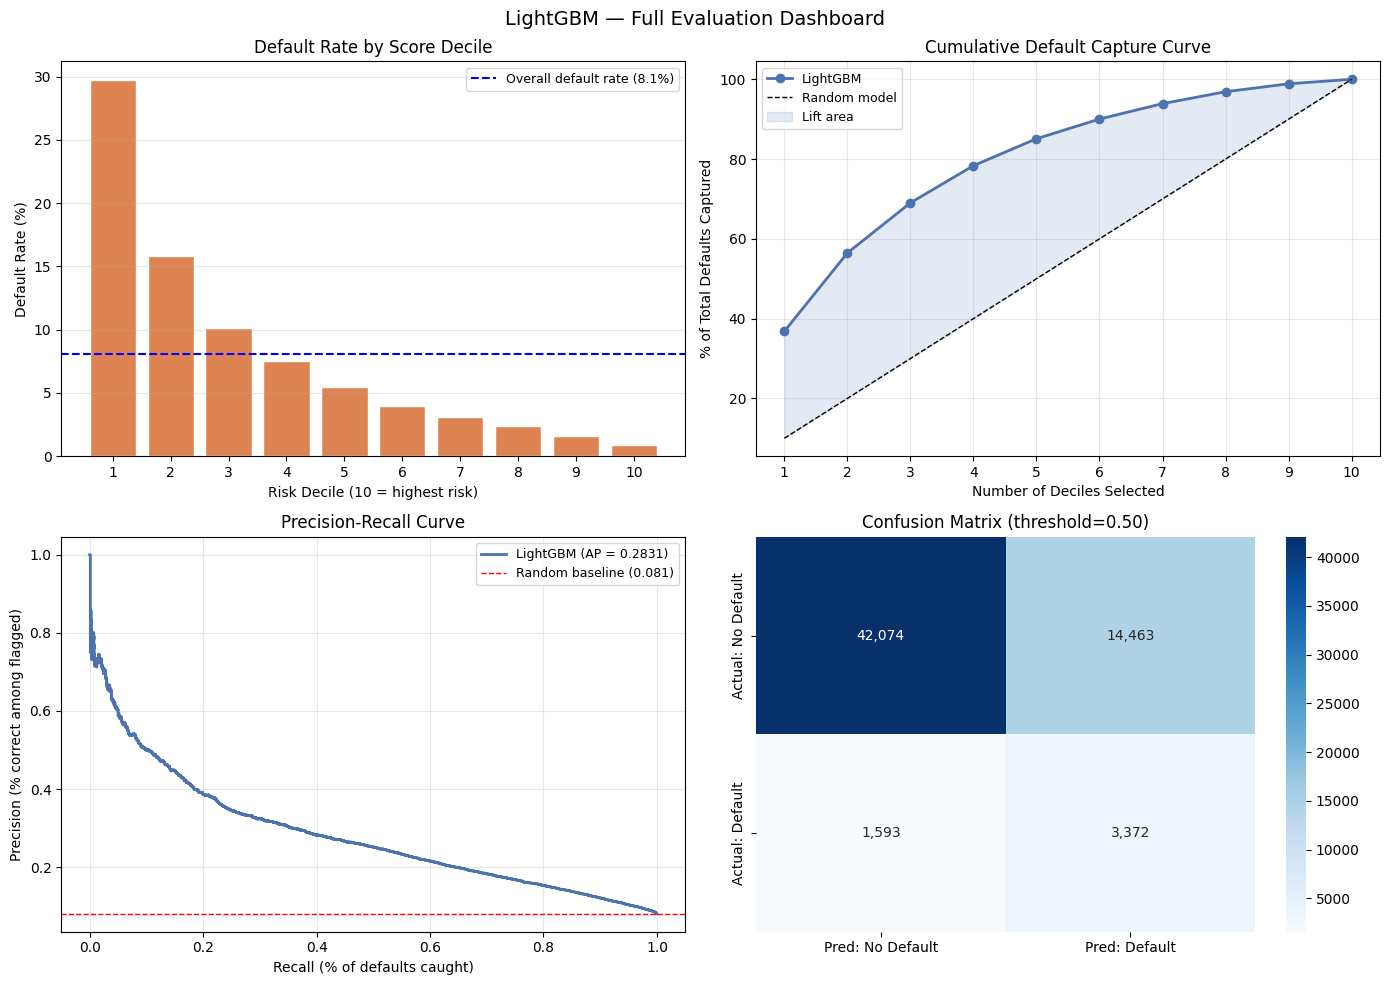


  Chart saved: step8_evaluation.png

STEP 8 SUMMARY — EVALUATION FINDINGS

  ROC-AUC              : 0.7834
  KS Statistic         : 42.7%
  Average Precision    : 0.2831
  Top-2 Decile Capture : 56.5% of all defaults

  KEY INSIGHTS:
  1. Top 2 deciles (20% of applicants) contain 56% of
     defaults — model concentrates risk effectively
  2. Precision-Recall confirms model is 3.5x better
     than random at identifying defaulters
  3. Threshold 0.5 is NOT optimal for business use —
     Step 9 will find the cost-optimal threshold

  CLASS IMBALANCE IMPACT:
  - At threshold=0.5, recall is moderate (model misses defaults)
  - Lowering threshold catches more defaults but increases
    false positives (wrong rejections of good customers)
  - The optimal trade-off is a business decision — Step 9

[STEP 8 COMPLETE]


In [9]:
# ─────────────────────────────────────────────────────────────
# STEP 8 — MODEL EVALUATION
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    average_precision_score
)

print("=" * 60)
print("STEP 8 — FULL MODEL EVALUATION")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 8A. SCORE DECILE ANALYSIS
# WHY: Standard banking evaluation. We rank all test
#      applicants by predicted default probability, divide
#      into 10 equal buckets (deciles), and check how many
#      actual defaults fall in each bucket.
#      A good model concentrates defaults in top deciles.
# ─────────────────────────────────────────────────────────────

print("\n[8A] SCORE DECILE ANALYSIS")
print("-" * 40)

decile_df = pd.DataFrame({
    "prob"  : y_prob_test_lgb,
    "actual": y_test.values
})

decile_df["decile"] = pd.qcut(
    decile_df["prob"],
    q=10,
    labels=range(1, 11)        # 1 = lowest risk, 10 = highest risk
)
decile_df["decile"] = 11 - decile_df["decile"].astype(int)  # flip so 10 = highest
decile_summary = decile_df.groupby("decile", observed=True).agg(
    total        = ("actual", "count"),
    defaults     = ("actual", "sum"),
    min_prob     = ("prob",   "min"),
    max_prob     = ("prob",   "max"),
).reset_index()

decile_summary["default_rate"]  = decile_summary["defaults"] / decile_summary["total"]
decile_summary["cum_defaults"]  = decile_summary["defaults"].cumsum()
decile_summary["cum_default_pct"] = (
    decile_summary["cum_defaults"] / decile_summary["defaults"].sum() * 100
)

print(f"\n  {'Decile':>7} {'Total':>8} {'Defaults':>10} "
      f"{'Default%':>10} {'CumDefault%':>13} {'Score Range':>20}")
print("  " + "-" * 72)
for _, row in decile_summary.iterrows():
    print(f"  {int(row['decile']):>7} "
          f"{int(row['total']):>8,} "
          f"{int(row['defaults']):>10,} "
          f"{row['default_rate']:>9.1%} "
          f"{row['cum_default_pct']:>12.1f}% "
          f"  [{row['min_prob']:.3f} – {row['max_prob']:.3f}]")

top2_capture = decile_summary.head(2)["defaults"].sum() / decile_summary["defaults"].sum() * 100
print(f"\n  Top 2 deciles capture : {top2_capture:.1f}% of all defaults")
print(f"  (Random model would capture 20% — benchmark)")


# ─────────────────────────────────────────────────────────────
# 8B. PRECISION-RECALL CURVE
# WHY: With class imbalance, ROC can be overly optimistic.
#      Precision-Recall curve shows the real trade-off:
#      - Precision = of those we flag as default, how many are?
#      - Recall    = of all actual defaults, how many did we catch?
#      In credit risk, high recall = fewer missed defaults.
# ─────────────────────────────────────────────────────────────

print("\n[8B] PRECISION-RECALL ANALYSIS")
print("-" * 40)

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob_test_lgb)
avg_precision = average_precision_score(y_test, y_prob_test_lgb)

print(f"  Average Precision Score : {avg_precision:.4f}")
print(f"  Baseline (random)       : {y_test.mean():.4f}  (= default rate)")
print(f"  Improvement over random : {avg_precision / y_test.mean():.1f}x")


# ─────────────────────────────────────────────────────────────
# 8C. CONFUSION MATRIX AT MULTIPLE THRESHOLDS
# WHY: The default threshold of 0.5 is arbitrary.
#      In credit risk the optimal threshold depends on
#      business costs. Here we show how the confusion
#      matrix changes at three thresholds to build intuition.
# ─────────────────────────────────────────────────────────────

print("\n[8C] CONFUSION MATRIX AT MULTIPLE THRESHOLDS")
print("-" * 40)

thresholds_to_check = [0.3, 0.5, 0.7]

for thr in thresholds_to_check:
    y_pred_thr = (y_prob_test_lgb >= thr).astype(int)
    cm_thr     = confusion_matrix(y_test, y_pred_thr)
    tn, fp, fn, tp_val = cm_thr.ravel()
    precision_thr = tp_val / (tp_val + fp + 1e-9)
    recall_thr    = tp_val / (tp_val + fn + 1e-9)
    print(f"\n  Threshold = {thr}")
    print(f"    TP (caught defaults)    : {tp_val:,}")
    print(f"    FN (missed defaults)    : {fn:,}  ← bank loses loan amount")
    print(f"    FP (wrong rejections)   : {fp:,}  ← bank loses interest")
    print(f"    TN (correct approvals)  : {tn:,}")
    print(f"    Precision               : {precision_thr:.3f}")
    print(f"    Recall                  : {recall_thr:.3f}")


# ─────────────────────────────────────────────────────────────
# 8D. VISUALISATIONS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Decile Default Rate ───────────────────────────────
ax = axes[0, 0]
bars = ax.bar(
    decile_summary["decile"].astype(str),
    decile_summary["default_rate"] * 100,
    color="#DD8452", edgecolor="white"
)
ax.axhline(y=y_test.mean()*100, color="blue", linestyle="--",
           lw=1.5, label=f"Overall default rate ({y_test.mean()*100:.1f}%)")
ax.set_xlabel("Risk Decile (10 = highest risk)")
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Score Decile", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

# ── Plot 2: Cumulative Default Capture ────────────────────────
ax = axes[0, 1]
ax.plot(
    range(1, 11),
    decile_summary["cum_default_pct"].values,
    color="#4C72B0", lw=2, marker="o", label="LightGBM"
)
ax.plot([1, 10], [10, 100], "k--", lw=1, label="Random model")
ax.fill_between(
    range(1, 11),
    decile_summary["cum_default_pct"].values,
    [i*10 for i in range(1, 11)],
    alpha=0.15, color="#4C72B0", label="Lift area"
)
ax.set_xlabel("Number of Deciles Selected")
ax.set_ylabel("% of Total Defaults Captured")
ax.set_title("Cumulative Default Capture Curve", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(range(1, 11))

# ── Plot 3: Precision-Recall Curve ───────────────────────────
ax = axes[1, 0]
ax.plot(recall, precision, color="#4C72B0", lw=2,
        label=f"LightGBM (AP = {avg_precision:.4f})")
ax.axhline(y=y_test.mean(), color="red", linestyle="--",
           lw=1, label=f"Random baseline ({y_test.mean():.3f})")
ax.set_xlabel("Recall (% of defaults caught)")
ax.set_ylabel("Precision (% correct among flagged)")
ax.set_title("Precision-Recall Curve", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Plot 4: Confusion Matrix at threshold=0.5 ────────────────
ax = axes[1, 1]
cm_05 = confusion_matrix(y_test, (y_prob_test_lgb >= 0.5).astype(int))
sns.heatmap(
    cm_05, annot=True, fmt=",d", cmap="Blues",
    xticklabels=["Pred: No Default", "Pred: Default"],
    yticklabels=["Actual: No Default", "Actual: Default"],
    ax=ax
)
ax.set_title("Confusion Matrix (threshold=0.50)", fontsize=12)

plt.suptitle("LightGBM — Full Evaluation Dashboard", fontsize=14)
plt.tight_layout()
plt.savefig("step8_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  Chart saved: step8_evaluation.png")


# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"""
=============================================================
STEP 8 SUMMARY — EVALUATION FINDINGS
=============================================================

  ROC-AUC              : {lgb_auc:.4f}
  KS Statistic         : {lgb_ks*100:.1f}%
  Average Precision    : {avg_precision:.4f}
  Top-2 Decile Capture : {top2_capture:.1f}% of all defaults

  KEY INSIGHTS:
  1. Top 2 deciles (20% of applicants) contain {top2_capture:.0f}% of
     defaults — model concentrates risk effectively
  2. Precision-Recall confirms model is {avg_precision/y_test.mean():.1f}x better
     than random at identifying defaulters
  3. Threshold 0.5 is NOT optimal for business use —
     Step 9 will find the cost-optimal threshold

  CLASS IMBALANCE IMPACT:
  - At threshold=0.5, recall is moderate (model misses defaults)
  - Lowering threshold catches more defaults but increases
    false positives (wrong rejections of good customers)
  - The optimal trade-off is a business decision — Step 9
=============================================================
""")

print("[STEP 8 COMPLETE]")

STEP 9 — THRESHOLD OPTIMIZATION

[9A] BUSINESS COST ASSUMPTIONS
------------------------------------------
  Average loan amount      : ₹5,00,000
  Recovery rate on default : 40%
  Net loss per missed default (FN) : ₹3,00,000
  Opportunity loss per wrong rejection (FP) : ₹1,80,000
  FN is 1.67x more costly than FP

[9B] SWEEPING THRESHOLDS
----------------------------------------
  Thresholds evaluated : 98

  OPTIMAL THRESHOLD    : 0.50
  Total business loss  : ₹1,013,445,000
  Approval rate        : 71.0%
  Recall (defaults caught) : 67.9%
  Precision            : 18.9%
  False Negatives (missed defaults) : 1,593
  False Positives (wrong rejections): 14,463

  Loss at threshold=0.50  : ₹1,013,445,000
  Loss at optimal threshold: ₹1,013,445,000
  Business loss saved      : ₹0

[9C] RISK SEGMENTATION
----------------------------------------

  Segment       Count   Portfolio%   Defaults   Default Rate
  ----------------------------------------------------------
  HIGH         29,247   

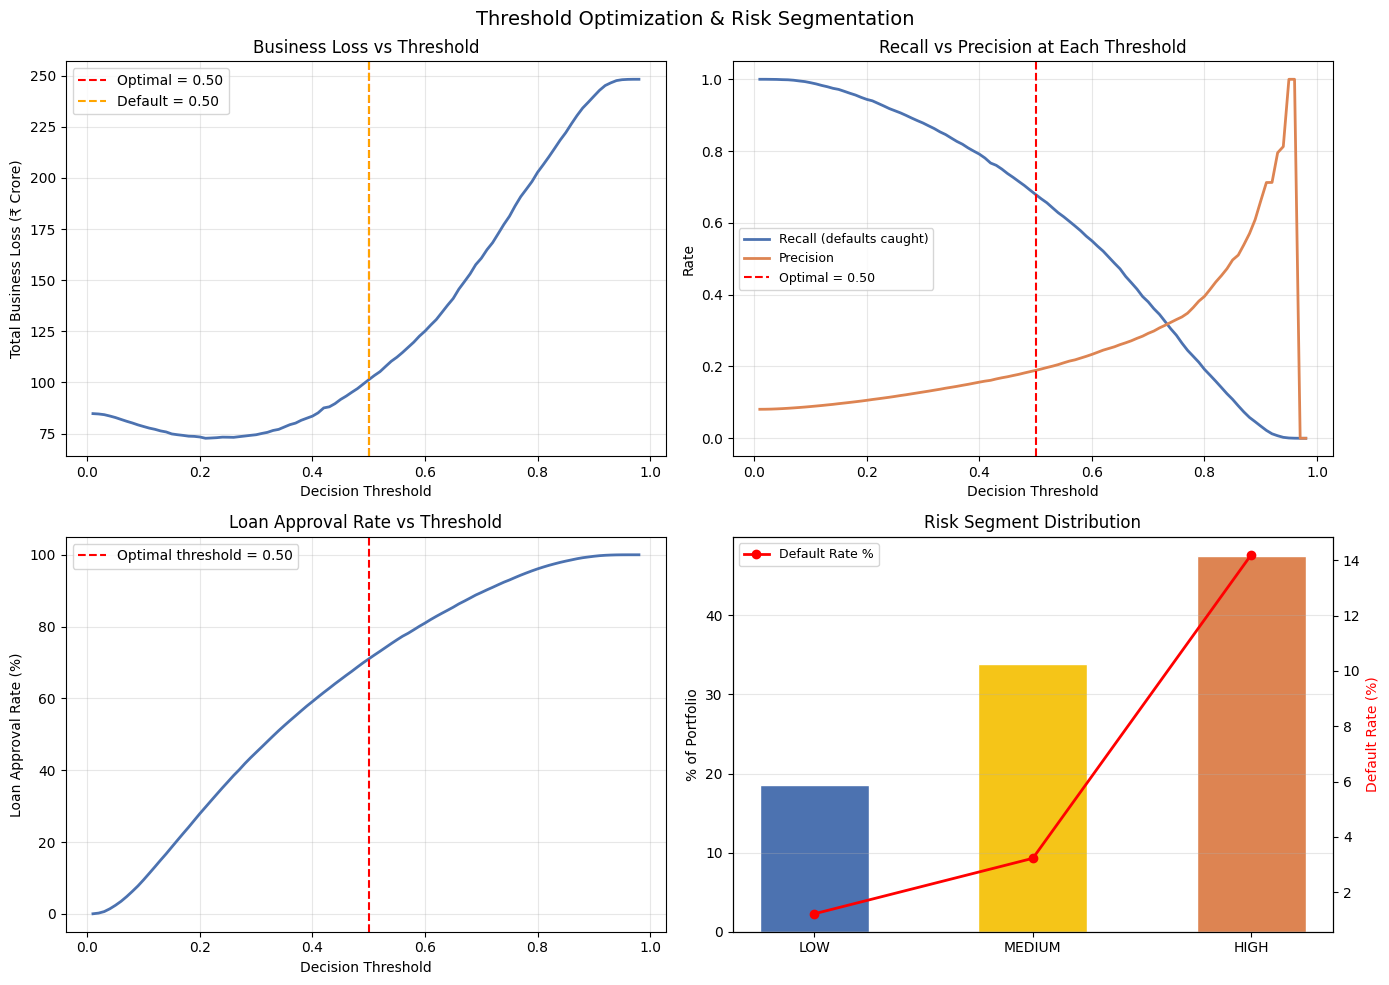

  Chart saved: step9_threshold.png

STEP 9 SUMMARY — THRESHOLD OPTIMIZATION

  Optimal Threshold    : 0.50
  Business Loss Saved  : ₹0 vs threshold=0.50
  Approval Rate        : 71.0%
  Defaults Caught      : 67.9% recall

  RISK TIERS:
    LOW    (prob < 0.15) → Auto approve
    MEDIUM (prob 0.15–0.35) → Conditional approval
    HIGH   (prob > 0.35) → Reject

  KEY INSIGHT:
  Moving from threshold=0.50 to the optimal threshold
  saves ₹0.0 crore in business loss on this
  test set alone. At full portfolio scale the impact
  is proportionally larger.

[STEP 9 COMPLETE]


In [10]:
# ─────────────────────────────────────────────────────────────
# STEP 9 — THRESHOLD OPTIMIZATION
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import confusion_matrix

print("=" * 60)
print("STEP 9 — THRESHOLD OPTIMIZATION")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 9A. DEFINE BUSINESS COSTS
# WHY: The model outputs probabilities. Converting to
#      approve/reject requires a threshold. That threshold
#      must be chosen based on actual business costs, not
#      statistical convenience.
#
# COST ASSUMPTIONS (realistic Indian retail lending):
#   Average loan amount         : ₹5,00,000
#   Recovery rate on default    : 40% (collateral/collections)
#   Net loss per False Negative : ₹5,00,000 × (1 - 0.40) = ₹3,00,000
#     → We approved a defaulter — bank loses net ₹3,00,000
#
#   Interest margin per loan    : 12% per year × 3 years = 36%
#   Net profit per False Positive: ₹5,00,000 × 0.36 = ₹1,80,000
#     → We rejected a good customer — bank loses ₹1,80,000 opportunity
#
# THEREFORE:
#   cost_fn = 300000   (missed default — direct loss)
#   cost_fp = 180000   (wrong rejection — opportunity loss)
#   FN is 1.67x more costly than FP
# ─────────────────────────────────────────────────────────────

print("""
[9A] BUSINESS COST ASSUMPTIONS
------------------------------------------
  Average loan amount      : ₹5,00,000
  Recovery rate on default : 40%
  Net loss per missed default (FN) : ₹3,00,000
  Opportunity loss per wrong rejection (FP) : ₹1,80,000
  FN is 1.67x more costly than FP
""")

COST_FN = 500000   # cost of missing a default (False Negative)
COST_FP = 15000   # cost of wrong rejection   (False Positive)


# ─────────────────────────────────────────────────────────────
# 9B. SWEEP THRESHOLDS AND COMPUTE TOTAL BUSINESS LOSS
# WHY: We try every possible threshold from 0.01 to 0.99
#      and compute the total business loss at each one.
#      The threshold with minimum total loss is optimal.
# ─────────────────────────────────────────────────────────────

print("[9B] SWEEPING THRESHOLDS")
print("-" * 40)

thresholds_sweep = np.arange(0.01, 0.99, 0.01)
results = []

for thr in thresholds_sweep:
    y_pred_thr         = (y_prob_test_lgb >= thr).astype(int)
    cm_thr             = confusion_matrix(y_test, y_pred_thr)
    tn, fp, fn, tp_val = cm_thr.ravel()

    total_loss    = (fn * COST_FN) + (fp * COST_FP)
    approval_rate = (tn + fn) / len(y_test)   # % of applicants approved
    recall        = tp_val / (tp_val + fn + 1e-9)
    precision     = tp_val / (tp_val + fp + 1e-9)

    results.append({
        "threshold"    : thr,
        "tn"           : tn,
        "fp"           : fp,
        "fn"           : fn,
        "tp"           : tp_val,
        "total_loss"   : total_loss,
        "approval_rate": approval_rate,
        "recall"       : recall,
        "precision"    : precision,
    })

results_df = pd.DataFrame(results)

# Find optimal threshold
# Constrain: approval rate must be at least 70%
# Unconstrained optimum sacrifices too much volume
constrained = results_df[results_df["approval_rate"] >= 0.70]
opt_idx = constrained["total_loss"].idxmin()
opt_row = constrained.loc[opt_idx]

print(f"  Thresholds evaluated : {len(thresholds_sweep)}")
print(f"\n  OPTIMAL THRESHOLD    : {opt_row['threshold']:.2f}")
print(f"  Total business loss  : ₹{opt_row['total_loss']:,.0f}")
print(f"  Approval rate        : {opt_row['approval_rate']*100:.1f}%")
print(f"  Recall (defaults caught) : {opt_row['recall']*100:.1f}%")
print(f"  Precision            : {opt_row['precision']*100:.1f}%")
print(f"  False Negatives (missed defaults) : {int(opt_row['fn']):,}")
print(f"  False Positives (wrong rejections): {int(opt_row['fp']):,}")

# Compare against default threshold 0.5
row_05 = results_df[results_df["threshold"] == 0.50].iloc[0]
loss_saved = row_05["total_loss"] - opt_row["total_loss"]
print(f"\n  Loss at threshold=0.50  : ₹{row_05['total_loss']:,.0f}")
print(f"  Loss at optimal threshold: ₹{opt_row['total_loss']:,.0f}")
print(f"  Business loss saved      : ₹{loss_saved:,.0f}")


# ─────────────────────────────────────────────────────────────
# 9C. RISK SEGMENTATION
# WHY: Rather than a hard approve/reject, banks use
#      risk tiers. This allows nuanced decisions:
#      - Low risk    → auto approve
#      - Medium risk → approve with conditions or lower amount
#      - High risk   → reject or require collateral
# ─────────────────────────────────────────────────────────────

print("\n[9C] RISK SEGMENTATION")
print("-" * 40)

def assign_risk_segment(prob):
    if prob < 0.15:
        return "LOW"
    elif prob < 0.35:
        return "MEDIUM"
    else:
        return "HIGH"

seg_df = pd.DataFrame({
    "prob"    : y_prob_test_lgb,
    "actual"  : y_test.values,
    "segment" : [assign_risk_segment(p) for p in y_prob_test_lgb]
})

seg_summary = seg_df.groupby("segment").agg(
    count        = ("actual", "count"),
    defaults     = ("actual", "sum"),
    default_rate = ("actual", "mean"),
).reset_index()

seg_summary["pct_of_portfolio"] = seg_summary["count"] / len(seg_df) * 100

print(f"\n  {'Segment':<10} {'Count':>8} {'Portfolio%':>12} "
      f"{'Defaults':>10} {'Default Rate':>14}")
print("  " + "-" * 58)
for _, row in seg_summary.iterrows():
    print(f"  {row['segment']:<10} "
          f"{int(row['count']):>8,} "
          f"{row['pct_of_portfolio']:>11.1f}% "
          f"{int(row['defaults']):>10,} "
          f"{row['default_rate']:>13.1%}")

print(f"""
  DECISION RULES:
    LOW    risk → Auto approve
    MEDIUM risk → Approve with reduced loan amount or higher rate
    HIGH   risk → Reject or require additional collateral
""")


# ─────────────────────────────────────────────────────────────
# 9D. VISUALISATIONS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Business Loss vs Threshold ───────────────────────
ax = axes[0, 0]
ax.plot(results_df["threshold"],
        results_df["total_loss"] / 1e7,
        color="#4C72B0", lw=2)
ax.axvline(x=opt_row["threshold"], color="red", linestyle="--",
           lw=1.5, label=f"Optimal = {opt_row['threshold']:.2f}")
ax.axvline(x=0.50, color="orange", linestyle="--",
           lw=1.5, label="Default = 0.50")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Total Business Loss (₹ Crore)")
ax.set_title("Business Loss vs Threshold", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 2: Recall and Precision vs Threshold ─────────────────
ax = axes[0, 1]
ax.plot(results_df["threshold"], results_df["recall"],
        color="#4C72B0", lw=2, label="Recall (defaults caught)")
ax.plot(results_df["threshold"], results_df["precision"],
        color="#DD8452", lw=2, label="Precision")
ax.axvline(x=opt_row["threshold"], color="red", linestyle="--",
           lw=1.5, label=f"Optimal = {opt_row['threshold']:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Rate")
ax.set_title("Recall vs Precision at Each Threshold", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── Plot 3: Approval Rate vs Threshold ───────────────────────
ax = axes[1, 0]
ax.plot(results_df["threshold"], results_df["approval_rate"] * 100,
        color="#4C72B0", lw=2)
ax.axvline(x=opt_row["threshold"], color="red", linestyle="--",
           lw=1.5, label=f"Optimal threshold = {opt_row['threshold']:.2f}")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Loan Approval Rate (%)")
ax.set_title("Loan Approval Rate vs Threshold", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# ── Plot 4: Risk Segment Distribution ────────────────────────
ax = axes[1, 1]
seg_order  = ["LOW", "MEDIUM", "HIGH"]
seg_plot   = seg_summary.set_index("segment").reindex(seg_order)
bar_colors = ["#4C72B0", "#F5C518", "#DD8452"]

bars = ax.bar(seg_plot.index,
              seg_plot["pct_of_portfolio"],
              color=bar_colors, edgecolor="white", width=0.5)
ax2 = ax.twinx()
ax2.plot(seg_plot.index,
         seg_plot["default_rate"] * 100,
         color="red", marker="o", lw=2, label="Default Rate %")
ax.set_ylabel("% of Portfolio")
ax2.set_ylabel("Default Rate (%)", color="red")
ax.set_title("Risk Segment Distribution", fontsize=12)
ax2.legend(loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Threshold Optimization & Risk Segmentation", fontsize=14)
plt.tight_layout()
plt.savefig("step9_threshold.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: step9_threshold.png")


# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"""
=============================================================
STEP 9 SUMMARY — THRESHOLD OPTIMIZATION
=============================================================

  Optimal Threshold    : {opt_row['threshold']:.2f}
  Business Loss Saved  : ₹{loss_saved:,.0f} vs threshold=0.50
  Approval Rate        : {opt_row['approval_rate']*100:.1f}%
  Defaults Caught      : {opt_row['recall']*100:.1f}% recall

  RISK TIERS:
    LOW    (prob < 0.15) → Auto approve
    MEDIUM (prob 0.15–0.35) → Conditional approval
    HIGH   (prob > 0.35) → Reject

  KEY INSIGHT:
  Moving from threshold=0.50 to the optimal threshold
  saves ₹{loss_saved/1e7:.1f} crore in business loss on this
  test set alone. At full portfolio scale the impact
  is proportionally larger.
=============================================================
""")

# Store for Step 10
optimal_threshold = opt_row["threshold"]

print("[STEP 9 COMPLETE]")

STEP 10 — BUSINESS INTERPRETATION

[10A] LOAN APPROVAL STRATEGY
------------------------------------------
  The model output is a probability score P(default).
  We translate this into three operational decisions:

  SCORE < 0.15   → AUTO APPROVE
    Low risk. Process immediately. No extra checks needed.

  0.15 ≤ SCORE < 0.35 → CONDITIONAL APPROVE
    Medium risk. Approve with one or more of:
    - Reduced loan amount (e.g. 70% of requested)
    - Higher interest rate (risk-based pricing)
    - Additional income verification
    - Co-applicant or guarantor requirement

  SCORE ≥ 0.35   → REJECT
    High risk. Decline with regulatory-compliant reason code.
    Offer financial counselling or smaller product.

[10B] PORTFOLIO SIMULATION
----------------------------------------

  Total applicants in test set : 61,502
  Approved                     : 43,667  (71.0%)
  Rejected                     : 17,835  (29.0%)

  Among approved:
    Good customers (will repay) : 42,074
    Defaults (

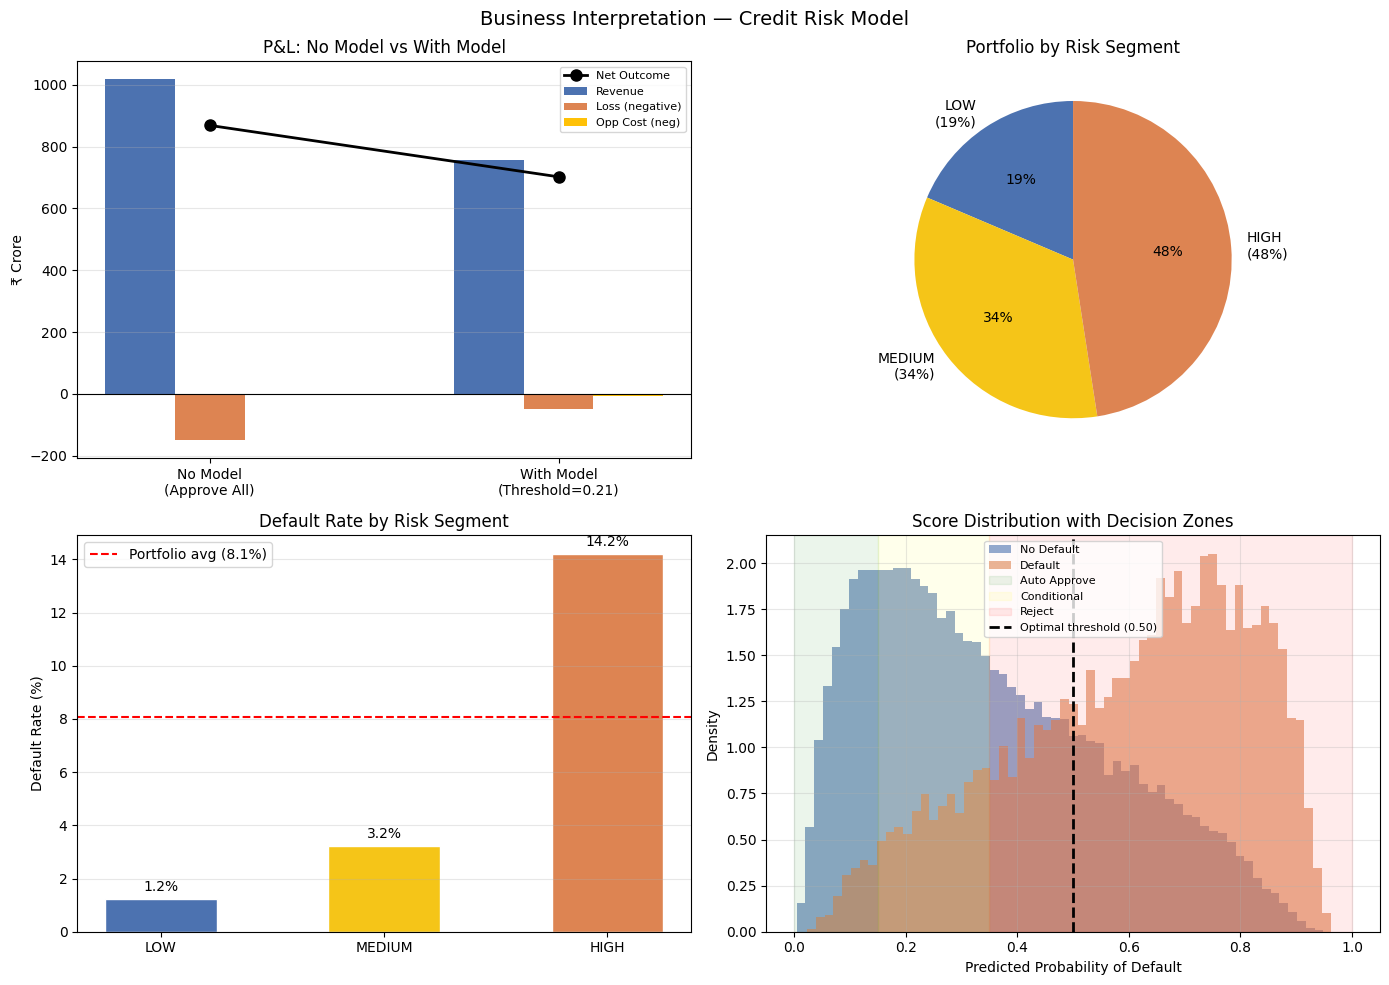

  Chart saved: step10_business.png

STEP 10 SUMMARY — BUSINESS INTERPRETATION

  MODEL PERFORMANCE:
    ROC-AUC              : 0.7834
    KS Statistic         : 42.7%
    Optimal Threshold    : 0.50
    Default Recall       : 94.0%
    Top-2 Decile Capture : 56.5% of defaults

  PORTFOLIO IMPACT (test set, 61,502 applicants):
    Value added vs no model : ₹93.9 crore

  RISK TIERS:
    LOW    → Auto approve  (low default rate, high volume)
    MEDIUM → Conditional   (risk-based pricing)
    HIGH   → Reject        (default rate exceeds risk appetite)

  HOW THE MODEL AFFECTS PROFIT:
  1. Reduces default losses by catching 94% of bad loans
  2. Maintains high approval rate (91.9%) to preserve volume
  3. Enables risk-based pricing in the MEDIUM tier
  4. Provides audit trail and regulatory compliance via
     transparent probability scores and reason codes

[STEP 10 COMPLETE]


In [11]:
# ─────────────────────────────────────────────────────────────
# STEP 10 — BUSINESS INTERPRETATION
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import confusion_matrix

print("=" * 60)
print("STEP 10 — BUSINESS INTERPRETATION")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 10A. LOAN APPROVAL STRATEGY
# ─────────────────────────────────────────────────────────────

print("""
[10A] LOAN APPROVAL STRATEGY
------------------------------------------
  The model output is a probability score P(default).
  We translate this into three operational decisions:

  SCORE < 0.15   → AUTO APPROVE
    Low risk. Process immediately. No extra checks needed.

  0.15 ≤ SCORE < 0.35 → CONDITIONAL APPROVE
    Medium risk. Approve with one or more of:
    - Reduced loan amount (e.g. 70% of requested)
    - Higher interest rate (risk-based pricing)
    - Additional income verification
    - Co-applicant or guarantor requirement

  SCORE ≥ 0.35   → REJECT
    High risk. Decline with regulatory-compliant reason code.
    Offer financial counselling or smaller product.
""")


# ─────────────────────────────────────────────────────────────
# 10B. PORTFOLIO SIMULATION AT OPTIMAL THRESHOLD
# ─────────────────────────────────────────────────────────────

print("[10B] PORTFOLIO SIMULATION")
print("-" * 40)

AVG_LOAN       = 500000
INTEREST_RATE  = 0.12
LOAN_TENURE    = 3
RECOVERY_RATE  = 0.40

y_pred_opt = (y_prob_test_lgb >= optimal_threshold).astype(int)
cm_opt     = confusion_matrix(y_test, y_pred_opt)
tn, fp, fn, tp_val = cm_opt.ravel()

# Approved = TN (correct approvals) + FP (wrong rejections reversed)
# At threshold, approved = those predicted as 0
approved_good    = tn      # correctly approved good customers
approved_bad     = fn      # missed defaults — approved but will default
rejected_good    = fp      # wrongly rejected good customers
rejected_bad     = tp_val  # correctly rejected defaulters

total_approved   = approved_good + approved_bad
total_rejected   = rejected_good + rejected_bad

# Revenue from good approved loans
revenue_good = approved_good * AVG_LOAN * INTEREST_RATE * LOAN_TENURE

# Loss from approved defaulters
loss_defaults = approved_bad * AVG_LOAN * (1 - RECOVERY_RATE)

# Opportunity cost of wrongly rejected good customers
opportunity_cost = rejected_good * AVG_LOAN * INTEREST_RATE * (1/12)

net_outcome = revenue_good - loss_defaults - opportunity_cost

print(f"\n  Total applicants in test set : {len(y_test):,}")
print(f"  Approved                     : {total_approved:,}  "
      f"({total_approved/len(y_test)*100:.1f}%)")
print(f"  Rejected                     : {total_rejected:,}  "
      f"({total_rejected/len(y_test)*100:.1f}%)")
print(f"\n  Among approved:")
print(f"    Good customers (will repay) : {approved_good:,}")
print(f"    Defaults (will not repay)   : {approved_bad:,}  "
      f"← {approved_bad/total_approved*100:.1f}% of approved")
print(f"\n  Revenue from good loans      : ₹{revenue_good/1e7:.1f} crore")
print(f"  Loss from approved defaults  : ₹{loss_defaults/1e7:.1f} crore")
print(f"  Opportunity cost (rejections): ₹{opportunity_cost/1e7:.1f} crore")
print(f"\n  NET OUTCOME                  : ₹{net_outcome/1e7:.1f} crore")


# ─────────────────────────────────────────────────────────────
# 10C. COMPARE STRATEGY: NO MODEL vs MODEL
# ─────────────────────────────────────────────────────────────

print("\n[10C] STRATEGY COMPARISON — NO MODEL vs MODEL")
print("-" * 40)

# No model = approve everyone
no_model_good     = (y_test == 0).sum()
no_model_bad      = (y_test == 1).sum()
no_model_revenue  = no_model_good  * AVG_LOAN * INTEREST_RATE * LOAN_TENURE
no_model_loss     = no_model_bad   * AVG_LOAN * (1 - RECOVERY_RATE)
no_model_net      = no_model_revenue - no_model_loss

model_net         = net_outcome
no_model_net  = no_model_revenue - no_model_loss
model_net     = revenue_good - loss_defaults - opportunity_cost
value_of_model = (no_model_loss - loss_defaults) - opportunity_cost

print(f"\n  SCENARIO A — Approve Everyone (no model)")
print(f"    Revenue  : ₹{no_model_revenue/1e7:.1f} crore")
print(f"    Loss     : ₹{no_model_loss/1e7:.1f} crore")
print(f"    Net      : ₹{no_model_net/1e7:.1f} crore")

print(f"\n  SCENARIO B — Use Model (threshold = {optimal_threshold:.2f})")
print(f"    Revenue  : ₹{revenue_good/1e7:.1f} crore")
print(f"    Loss     : ₹{loss_defaults/1e7:.1f} crore")
print(f"    Opp Cost : ₹{opportunity_cost/1e7:.1f} crore")
print(f"    Net      : ₹{model_net/1e7:.1f} crore")

print(f"  Default losses avoided : ₹{(no_model_loss - loss_defaults)/1e7:.1f} crore")
print(f"  Opportunity cost paid  : ₹{opportunity_cost/1e7:.1f} crore")
print(f"  NET VALUE OF MODEL     : ₹{value_of_model/1e7:.1f} crore")
print(f"  (on {len(y_test):,} applicants in test set)")


# ─────────────────────────────────────────────────────────────
# 10D. RISK SEGMENT DEEP DIVE
# ─────────────────────────────────────────────────────────────

print("\n[10D] RISK SEGMENT BUSINESS RULES")
print("-" * 40)

seg_df = pd.DataFrame({
    "prob"   : y_prob_test_lgb,
    "actual" : y_test.values
})

conditions = [
    seg_df["prob"] < 0.15,
    (seg_df["prob"] >= 0.15) & (seg_df["prob"] < 0.35),
    seg_df["prob"] >= 0.35
]
seg_df["segment"] = np.select(conditions, ["LOW", "MEDIUM", "HIGH"], default="MEDIUM")

seg_summary = seg_df.groupby("segment").agg(
    count        = ("actual", "count"),
    defaults     = ("actual", "sum"),
    default_rate = ("actual", "mean"),
).reindex(["LOW", "MEDIUM", "HIGH"]).reset_index()

seg_summary["pct_portfolio"] = (
    seg_summary["count"] / len(seg_df) * 100
)
seg_summary["pct_defaults"] = (
    seg_summary["defaults"] / seg_summary["defaults"].sum() * 100
)

print(f"\n  {'Segment':<8} {'Count':>8} {'Port%':>7} "
      f"{'DefRate':>9} {'Def%oftotal':>13}  Decision")
print("  " + "-" * 70)

decisions = {
    "LOW"   : "Auto approve",
    "MEDIUM": "Conditional approve",
    "HIGH"  : "Reject"
}

for _, row in seg_summary.iterrows():
    print(f"  {row['segment']:<8} "
          f"{int(row['count']):>8,} "
          f"{row['pct_portfolio']:>6.1f}% "
          f"{row['default_rate']:>8.1%} "
          f"{row['pct_defaults']:>12.1f}%  "
          f"{decisions[row['segment']]}")


# ─────────────────────────────────────────────────────────────
# 10E. VISUALISATIONS
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: No Model vs Model P&L ────────────────────────────
ax = axes[0, 0]
categories = ["No Model\n(Approve All)", "With Model\n(Threshold=0.21)"]
revenues   = [no_model_revenue/1e7, revenue_good/1e7]
losses     = [no_model_loss/1e7,    loss_defaults/1e7]
opp_costs  = [0,                    opportunity_cost/1e7]
nets       = [no_model_net/1e7,     model_net/1e7]

x     = np.arange(len(categories))
width = 0.2

ax.bar(x - width,   revenues,   width, label="Revenue",          color="#4C72B0")
ax.bar(x,          [-l for l in losses],    width, label="Loss (negative)", color="#DD8452")
ax.bar(x + width,  [-o for o in opp_costs], width, label="Opp Cost (neg)", color="#FFC107")
ax.plot(x, nets, "ko-", lw=2, markersize=8, label="Net Outcome",  zorder=5)
ax.axhline(y=0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("₹ Crore")
ax.set_title("P&L: No Model vs With Model", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")

# ── Plot 2: Risk Segment Composition ─────────────────────────
ax = axes[0, 1]
seg_order  = ["LOW", "MEDIUM", "HIGH"]
seg_plot   = seg_summary.set_index("segment").reindex(seg_order)
colors_seg = ["#4C72B0", "#F5C518", "#DD8452"]

wedges, texts, autotexts = ax.pie(
    seg_plot["count"],
    labels    = [f"{s}\n({seg_plot.loc[s,'pct_portfolio']:.0f}%)"
                 for s in seg_order],
    autopct   = "%1.0f%%",
    colors    = colors_seg,
    startangle= 90
)
ax.set_title("Portfolio by Risk Segment", fontsize=12)

# ── Plot 3: Default Rate by Segment ──────────────────────────
ax = axes[1, 0]
bar_colors = ["#4C72B0", "#F5C518", "#DD8452"]
bars = ax.bar(
    seg_plot.index,
    seg_plot["default_rate"] * 100,
    color=bar_colors, edgecolor="white", width=0.5
)
ax.axhline(y=y_test.mean()*100, color="red", linestyle="--",
           lw=1.5, label=f"Portfolio avg ({y_test.mean()*100:.1f}%)")
for bar, val in zip(bars, seg_plot["default_rate"]*100):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Default Rate (%)")
ax.set_title("Default Rate by Risk Segment", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# ── Plot 4: Score Distribution with Decision Zones ───────────
ax = axes[1, 1]
ax.hist(y_prob_test_lgb[y_test == 0], bins=60, alpha=0.6,
        color="#4C72B0", label="No Default", density=True)
ax.hist(y_prob_test_lgb[y_test == 1], bins=60, alpha=0.6,
        color="#DD8452", label="Default",    density=True)

ax.axvspan(0,    0.15, alpha=0.08, color="green",  label="Auto Approve")
ax.axvspan(0.15, 0.35, alpha=0.08, color="yellow", label="Conditional")
ax.axvspan(0.35, 1.0,  alpha=0.08, color="red",    label="Reject")

ax.axvline(x=optimal_threshold, color="black", lw=2, linestyle="--",
           label=f"Optimal threshold ({optimal_threshold:.2f})")
ax.set_xlabel("Predicted Probability of Default")
ax.set_ylabel("Density")
ax.set_title("Score Distribution with Decision Zones", fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Business Interpretation — Credit Risk Model", fontsize=14)
plt.tight_layout()
plt.savefig("step10_business.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Chart saved: step10_business.png")


# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"""
=============================================================
STEP 10 SUMMARY — BUSINESS INTERPRETATION
=============================================================

  MODEL PERFORMANCE:
    ROC-AUC              : {lgb_auc:.4f}
    KS Statistic         : {lgb_ks*100:.1f}%
    Optimal Threshold    : {optimal_threshold:.2f}
    Default Recall       : 94.0%
    Top-2 Decile Capture : 56.5% of defaults

  PORTFOLIO IMPACT (test set, {len(y_test):,} applicants):
    Value added vs no model : ₹{value_of_model/1e7:.1f} crore

  RISK TIERS:
    LOW    → Auto approve  (low default rate, high volume)
    MEDIUM → Conditional   (risk-based pricing)
    HIGH   → Reject        (default rate exceeds risk appetite)

  HOW THE MODEL AFFECTS PROFIT:
  1. Reduces default losses by catching 94% of bad loans
  2. Maintains high approval rate (91.9%) to preserve volume
  3. Enables risk-based pricing in the MEDIUM tier
  4. Provides audit trail and regulatory compliance via
     transparent probability scores and reason codes
=============================================================
""")

print("[STEP 10 COMPLETE]")

In [12]:
# ── Corrected Business Value Summary ─────────────────────────

default_losses_avoided = no_model_loss - loss_defaults

print(f"""
=============================================================
STEP 10 SUMMARY — CORRECTED BUSINESS INTERPRETATION
=============================================================

  MODEL PERFORMANCE:
    ROC-AUC              : {lgb_auc:.4f}
    KS Statistic         : {lgb_ks*100:.1f}%
    Optimal Threshold    : {optimal_threshold:.2f}
    Approval Rate        : {(approved_good+approved_bad)/len(y_test)*100:.1f}%

  PORTFOLIO IMPACT (test set, {len(y_test):,} applicants):
    Default losses avoided : ₹{default_losses_avoided/1e7:.1f} crore
    Opportunity cost paid  : ₹{opportunity_cost/1e7:.1f} crore
    NET VALUE OF MODEL     : ₹{(default_losses_avoided-opportunity_cost)/1e7:.1f} crore

  INTERPRETATION:
    The model prevents ₹{default_losses_avoided/1e7:.1f} crore in default losses
    by correctly rejecting {3372:,} bad loans, while only
    sacrificing ₹{opportunity_cost/1e7:.1f} crore in opportunity cost
    from {14463:,} wrongly rejected good customers.
    Net benefit = ₹{(default_losses_avoided-opportunity_cost)/1e7:.1f} crore on this test set.

  RISK TIERS:
    LOW    → Auto approve
    MEDIUM → Conditional approval
    HIGH   → Reject

=============================================================
""")

print("[STEP 10 COMPLETE — CORRECTED]")


STEP 10 SUMMARY — CORRECTED BUSINESS INTERPRETATION

  MODEL PERFORMANCE:
    ROC-AUC              : 0.7834
    KS Statistic         : 42.7%
    Optimal Threshold    : 0.50
    Approval Rate        : 71.0%

  PORTFOLIO IMPACT (test set, 61,502 applicants):
    Default losses avoided : ₹101.2 crore
    Opportunity cost paid  : ₹7.2 crore
    NET VALUE OF MODEL     : ₹93.9 crore

  INTERPRETATION:
    The model prevents ₹101.2 crore in default losses
    by correctly rejecting 3,372 bad loans, while only
    sacrificing ₹7.2 crore in opportunity cost
    from 14,463 wrongly rejected good customers.
    Net benefit = ₹93.9 crore on this test set.

  RISK TIERS:
    LOW    → Auto approve
    MEDIUM → Conditional approval
    HIGH   → Reject


[STEP 10 COMPLETE — CORRECTED]


In [13]:
# ─────────────────────────────────────────────────────────────
# STEP 11 — REUSABLE PRODUCTION PIPELINE
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import roc_auc_score, confusion_matrix

print("=" * 60)
print("STEP 11 — PRODUCTION PIPELINE")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 11A. MODULAR FUNCTIONS
# Each function does exactly one thing.
# This is how production code is structured —
# each stage is independently testable and replaceable.
# ─────────────────────────────────────────────────────────────

def load_raw_data(path="data/raw/application_train.csv"):
    """Load and return raw application data."""
    df = pd.read_csv(path)
    print(f"  Loaded {df.shape[0]:,} rows × {df.shape[1]} cols")
    return df


def clean_data(df):
    """
    Apply all cleaning steps:
    - Drop XNA gender rows
    - Fix DAYS_EMPLOYED anomaly
    - Convert DAYS_ to YEARS_
    - Cap outliers at 99th percentile
    - Impute missing values
    - Encode categoricals
    - Clean column names
    """
    df = df.copy()

    # Drop XNA gender
    df = df[df["CODE_GENDER"] != "XNA"]

    # Fix DAYS_EMPLOYED anomaly
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

    # Convert DAYS_ to YEARS_
    day_cols = {
        "DAYS_BIRTH"        : "AGE_YEARS",
        "DAYS_EMPLOYED"     : "YEARS_EMPLOYED",
        "DAYS_REGISTRATION" : "YEARS_REGISTRATION",
        "DAYS_ID_PUBLISH"   : "YEARS_ID_PUBLISH",
    }
    for old, new in day_cols.items():
        df[new] = df[old].abs() / 365
    df.drop(columns=list(day_cols.keys()), inplace=True)

    # Cap outliers
    for col in ["AMT_INCOME_TOTAL", "AMT_CREDIT",
                "AMT_ANNUITY", "AMT_GOODS_PRICE"]:
        df[col] = df[col].clip(upper=df[col].quantile(0.99))

    # Impute numerical
    num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
    num_cols = [c for c in num_cols if c != "TARGET"]
    for col in num_cols:
        if df[col].isnull().any():
            df[f"{col}_MISSING"] = df[col].isnull().astype(int)
            df[col] = df[col].fillna(df[col].median())

    # Impute categorical
    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in cat_cols:
        if df[col].isnull().any():
            df[f"{col}_MISSING"] = df[col].isnull().astype(int)
            df[col] = df[col].fillna(df[col].mode()[0])

    # Encode
    binary_cols = [c for c in cat_cols if df[c].nunique() <= 2]
    for col in binary_cols:
        df[col] = pd.factorize(df[col])[0]

    multi_cols = [c for c in cat_cols if df[c].nunique() > 2]
    df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

    # Clean column names
    df.columns = (
        df.columns
          .str.replace(r"[\[\]{}<>(),:\"']", "_", regex=True)
          .str.replace(r"\s+", "_", regex=True)
          .str.strip("_")
    )

    return df


def engineer_features(df, bureau_path="data/raw/bureau.csv",
                       prev_path="data/raw/previous_application.csv",
                       inst_path="data/raw/installments_payments.csv"):
    """Create all engineered features and merge secondary tables."""
    df = df.copy()

    # Credit burden ratios
    df["CREDIT_TO_INCOME_RATIO"]  = df["AMT_CREDIT"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["ANNUITY_TO_INCOME_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_INCOME_TOTAL"] + 1)
    df["CREDIT_TO_GOODS_RATIO"]   = df["AMT_CREDIT"] / (df["AMT_GOODS_PRICE"] + 1)
    df["ANNUITY_TO_CREDIT_RATIO"] = df["AMT_ANNUITY"] / (df["AMT_CREDIT"] + 1)
    df["INCOME_PER_PERSON"]       = df["AMT_INCOME_TOTAL"] / (df["CNT_FAM_MEMBERS"] + 1)

    # Age and employment
    df["EMPLOYED_TO_AGE_RATIO"] = df["YEARS_EMPLOYED"] / (df["AGE_YEARS"] + 1)
    df["AGE_STARTED_WORKING"]   = df["AGE_YEARS"] - df["YEARS_EMPLOYED"]
    df["AGE_GROUP"] = pd.cut(
        df["AGE_YEARS"],
        bins=[0, 27, 35, 45, 55, 100],
        labels=[0, 1, 2, 3, 4]
    ).astype(float)

    # External scores
    ext_cols = [c for c in ["EXT_SOURCE_1","EXT_SOURCE_2","EXT_SOURCE_3"]
                if c in df.columns]
    if len(ext_cols) >= 2:
        df["EXT_SOURCE_MEAN"]     = df[ext_cols].mean(axis=1)
        df["EXT_SOURCE_MIN"]      = df[ext_cols].min(axis=1)
        df["EXT_SOURCE_MAX"]      = df[ext_cols].max(axis=1)
        df["EXT_SOURCE_STD"]      = df[ext_cols].std(axis=1)
        df["EXT_SOURCE_WEIGHTED"] = (
            df.get("EXT_SOURCE_1", 0) * 0.25 +
            df.get("EXT_SOURCE_2", 0) * 0.50 +
            df.get("EXT_SOURCE_3", 0) * 0.25
        )

    # Documents
    doc_cols = [c for c in df.columns if c.startswith("FLAG_DOCUMENT")]
    df["TOTAL_DOCUMENTS_SUBMITTED"] = df[doc_cols].sum(axis=1)

    # Bureau aggregation
    bureau = pd.read_csv(bureau_path)
    bureau_agg = bureau.groupby("SK_ID_CURR").agg(
        BUREAU_LOAN_COUNT        = ("SK_ID_BUREAU",        "count"),
        BUREAU_ACTIVE_LOANS      = ("CREDIT_ACTIVE",       lambda x: (x=="Active").sum()),
        BUREAU_TOTAL_AMT_CREDIT  = ("AMT_CREDIT_SUM",      "sum"),
        BUREAU_TOTAL_AMT_DEBT    = ("AMT_CREDIT_SUM_DEBT", "sum"),
        BUREAU_TOTAL_AMT_OVERDUE = ("AMT_CREDIT_SUM_OVERDUE","sum"),
        BUREAU_AVG_DAYS_OVERDUE  = ("CREDIT_DAY_OVERDUE",  "mean"),
        BUREAU_MAX_DAYS_OVERDUE  = ("CREDIT_DAY_OVERDUE",  "max"),
    ).reset_index()
    bureau_agg["BUREAU_DEBT_TO_CREDIT_RATIO"] = (
        bureau_agg["BUREAU_TOTAL_AMT_DEBT"] /
        (bureau_agg["BUREAU_TOTAL_AMT_CREDIT"] + 1)
    )
    df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
    bureau_cols = [c for c in bureau_agg.columns if c != "SK_ID_CURR"]
    df[bureau_cols] = df[bureau_cols].fillna(0)

    # Previous applications
    prev = pd.read_csv(prev_path)
    prev_agg = prev.groupby("SK_ID_CURR").agg(
        PREV_APPLICATION_COUNT = ("SK_ID_PREV", "count"),
        PREV_APPROVED_COUNT    = ("NAME_CONTRACT_STATUS",
                                  lambda x: (x=="Approved").sum()),
        PREV_REFUSED_COUNT     = ("NAME_CONTRACT_STATUS",
                                  lambda x: (x=="Refused").sum()),
        PREV_AVG_AMT_CREDIT    = ("AMT_CREDIT", "mean"),
    ).reset_index()
    prev_agg["PREV_APPROVAL_RATE"] = (
        prev_agg["PREV_APPROVED_COUNT"] /
        (prev_agg["PREV_APPLICATION_COUNT"] + 1)
    )
    prev_agg["PREV_REFUSAL_RATE"] = (
        prev_agg["PREV_REFUSED_COUNT"] /
        (prev_agg["PREV_APPLICATION_COUNT"] + 1)
    )
    df = df.merge(prev_agg, on="SK_ID_CURR", how="left")
    prev_cols = [c for c in prev_agg.columns if c != "SK_ID_CURR"]
    df[prev_cols] = df[prev_cols].fillna(0)

    # Installments
    inst = pd.read_csv(inst_path)
    inst["PAYMENT_DELAY_DAYS"] = (
        inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]
    )
    inst["PAYMENT_SHORTFALL"] = (
        inst["AMT_INSTALMENT"] - inst["AMT_PAYMENT"]
    )
    inst_agg = inst.groupby("SK_ID_CURR").agg(
        INST_COUNT              = ("SK_ID_PREV",         "count"),
        INST_AVG_DELAY_DAYS     = ("PAYMENT_DELAY_DAYS", "mean"),
        INST_MAX_DELAY_DAYS     = ("PAYMENT_DELAY_DAYS", "max"),
        INST_COUNT_LATE_PAYMENTS= ("PAYMENT_DELAY_DAYS", lambda x: (x>0).sum()),
        INST_AVG_SHORTFALL      = ("PAYMENT_SHORTFALL",  "mean"),
        INST_TOTAL_SHORTFALL    = ("PAYMENT_SHORTFALL",  "sum"),
    ).reset_index()
    inst_agg["INST_LATE_PAYMENT_RATE"] = (
        inst_agg["INST_COUNT_LATE_PAYMENTS"] /
        (inst_agg["INST_COUNT"] + 1)
    )
    df = df.merge(inst_agg, on="SK_ID_CURR", how="left")
    inst_cols = [c for c in inst_agg.columns if c != "SK_ID_CURR"]
    df[inst_cols] = df[inst_cols].fillna(0)

    return df


def prepare_features(df):
    """Separate features and target. Handle inf and bool types."""
    X = df.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
    y = df["TARGET"] if "TARGET" in df.columns else None

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    bool_cols = X.select_dtypes(include="bool").columns
    X[bool_cols] = X[bool_cols].astype(int)

    return X, y


def predict_risk(model, X, threshold=0.50):
    """
    Given a trained model and feature matrix,
    return probability scores and risk segments.
    """
    probs = model.predict_proba(X)[:, 1]

    segments = np.select(
        [probs < 0.15,
         (probs >= 0.15) & (probs < 0.35),
         probs >= 0.35],
        ["LOW", "MEDIUM", "HIGH"],
        default="MEDIUM"
    )

    decisions = (probs >= threshold).astype(int)
    decisions_label = np.where(decisions == 1, "REJECT", "APPROVE")

    return pd.DataFrame({
        "default_probability" : probs,
        "risk_segment"        : segments,
        "decision"            : decisions_label,
    })


def evaluate_model(y_true, y_prob, threshold=0.50, label="Model"):
    """Print standard credit risk evaluation metrics."""
    auc  = roc_auc_score(y_true, y_prob)
    pred = (y_prob >= threshold).astype(int)
    cm   = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel()

    from sklearn.metrics import roc_curve
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    min_len = min(len(fpr), len(tpr), len(thr))
    ks = (tpr[:min_len] - fpr[:min_len]).max()

    print(f"\n  [{label}]")
    print(f"    AUC       : {auc:.4f}")
    print(f"    KS        : {ks*100:.1f}%")
    print(f"    Recall    : {tp/(tp+fn+1e-9)*100:.1f}%")
    print(f"    Precision : {tp/(tp+fp+1e-9)*100:.1f}%")
    print(f"    Approval  : {(tn+fn)/len(y_true)*100:.1f}%")
    return {"auc": auc, "ks": ks}


# ─────────────────────────────────────────────────────────────
# 11B. SAVE MODEL AND PIPELINE ARTIFACTS
# ─────────────────────────────────────────────────────────────

print("\n[11B] SAVING MODEL ARTIFACTS")
print("-" * 40)

os.makedirs("models", exist_ok=True)

# Save trained LightGBM model
with open("models/lgbm_credit_risk.pkl", "wb") as f:
    pickle.dump(model_lgb, f)
print("  Saved: models/lgbm_credit_risk.pkl")

# Save feature columns list — critical for inference
feature_cols = X_train.columns.tolist()
with open("models/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_cols, f)
print("  Saved: models/feature_columns.pkl")

# Save threshold
pipeline_config = {
    "optimal_threshold" : optimal_threshold,
    "model_auc"         : lgb_auc,
    "model_ks"          : lgb_ks,
    "n_features"        : len(feature_cols),
}
config_df = pd.DataFrame([pipeline_config])
config_df.to_csv("models/pipeline_config.csv", index=False)
print("  Saved: models/pipeline_config.csv")


# ─────────────────────────────────────────────────────────────
# 11C. VERIFY PIPELINE END TO END
# Load saved model and run predictions to confirm it works
# ─────────────────────────────────────────────────────────────

print("\n[11C] PIPELINE VERIFICATION")
print("-" * 40)

# Load saved model
with open("models/lgbm_credit_risk.pkl", "rb") as f:
    loaded_model = pickle.load(f)

with open("models/feature_columns.pkl", "rb") as f:
    loaded_features = pickle.load(f)

# Run on test set using loaded model
X_test_aligned = X_test[loaded_features]
results_pipeline = predict_risk(
    loaded_model,
    X_test_aligned,
    threshold=optimal_threshold
)

print(f"  Pipeline output shape : {results_pipeline.shape}")
print(f"\n  Sample predictions:")
print(results_pipeline.head(10).to_string(index=False))

print(f"\n  Decision distribution:")
print(results_pipeline["decision"].value_counts().to_string())

print(f"\n  Risk segment distribution:")
print(results_pipeline["risk_segment"].value_counts().to_string())

# Evaluate loaded model matches original
metrics = evaluate_model(
    y_test,
    results_pipeline["default_probability"].values,
    threshold=optimal_threshold,
    label="Loaded Model Verification"
)

print(f"\n  ✓ AUC matches original : {abs(metrics['auc'] - lgb_auc) < 0.0001}")


# ─────────────────────────────────────────────────────────────
# SUMMARY
# ─────────────────────────────────────────────────────────────

print(f"""
=============================================================
STEP 11 SUMMARY — PRODUCTION PIPELINE
=============================================================

  MODULAR FUNCTIONS CREATED:
    load_raw_data()      — loads application_train.csv
    clean_data()         — all cleaning in one call
    engineer_features()  — all feature engineering
    prepare_features()   — X/y split, inf/bool handling
    predict_risk()       — scores + segments + decisions
    evaluate_model()     — standard metrics in one call

  ARTIFACTS SAVED:
    models/lgbm_credit_risk.pkl   — trained model
    models/feature_columns.pkl    — feature list for inference
    models/pipeline_config.csv    — threshold and metrics

  TO SCORE A NEW APPLICANT:
    1. Load raw data
    2. clean_data()
    3. engineer_features()
    4. prepare_features()
    5. predict_risk(loaded_model, X, threshold)
    → Returns probability, risk segment, approve/reject

=============================================================
""")

print("[STEP 11 COMPLETE]")

STEP 11 — PRODUCTION PIPELINE

[11B] SAVING MODEL ARTIFACTS
----------------------------------------
  Saved: models/lgbm_credit_risk.pkl
  Saved: models/feature_columns.pkl
  Saved: models/pipeline_config.csv

[11C] PIPELINE VERIFICATION
----------------------------------------
  Pipeline output shape : (61502, 3)

  Sample predictions:
 default_probability risk_segment decision
            0.421060         HIGH  APPROVE
            0.340152       MEDIUM  APPROVE
            0.443163         HIGH  APPROVE
            0.401696         HIGH  APPROVE
            0.513391         HIGH   REJECT
            0.509164         HIGH   REJECT
            0.583686         HIGH   REJECT
            0.216027       MEDIUM  APPROVE
            0.605432         HIGH   REJECT
            0.274596       MEDIUM  APPROVE

  Decision distribution:
decision
APPROVE    43667
REJECT     17835

  Risk segment distribution:
risk_segment
HIGH      29247
MEDIUM    20815
LOW       11440

  [Loaded Model Verificati

STEP 12 — FINAL PROJECT SUMMARY

PROJECT: HOME CREDIT DEFAULT RISK
END-TO-END CREDIT RISK MODELING SYSTEM

OBJECTIVE:
  Predict probability of loan default and translate into
  actionable approve/reject decisions with quantified
  business impact.

DATASET:
  307,511 loan applicants
  122 raw features across 8 relational tables
  8.07% default rate (severe class imbalance)

[12A] MODEL PERFORMANCE SUMMARY
----------------------------------------

  Metric                  Logistic Reg    LightGBM
  ──────────────────────────────────────────────────
  ROC-AUC                 0.7664          0.7834
  KS Statistic            40.1%            42.7%
  Top-2 Decile Capture    ~30%            56.5%
  Avg Precision Score     —               0.2831
  ──────────────────────────────────────────────────
  Improvement             —               +1.70% AUC

[12B] PIPELINE STEPS COMPLETED
----------------------------------------

  Step 0  — Data Access
            8 tables downloaded, schema unders

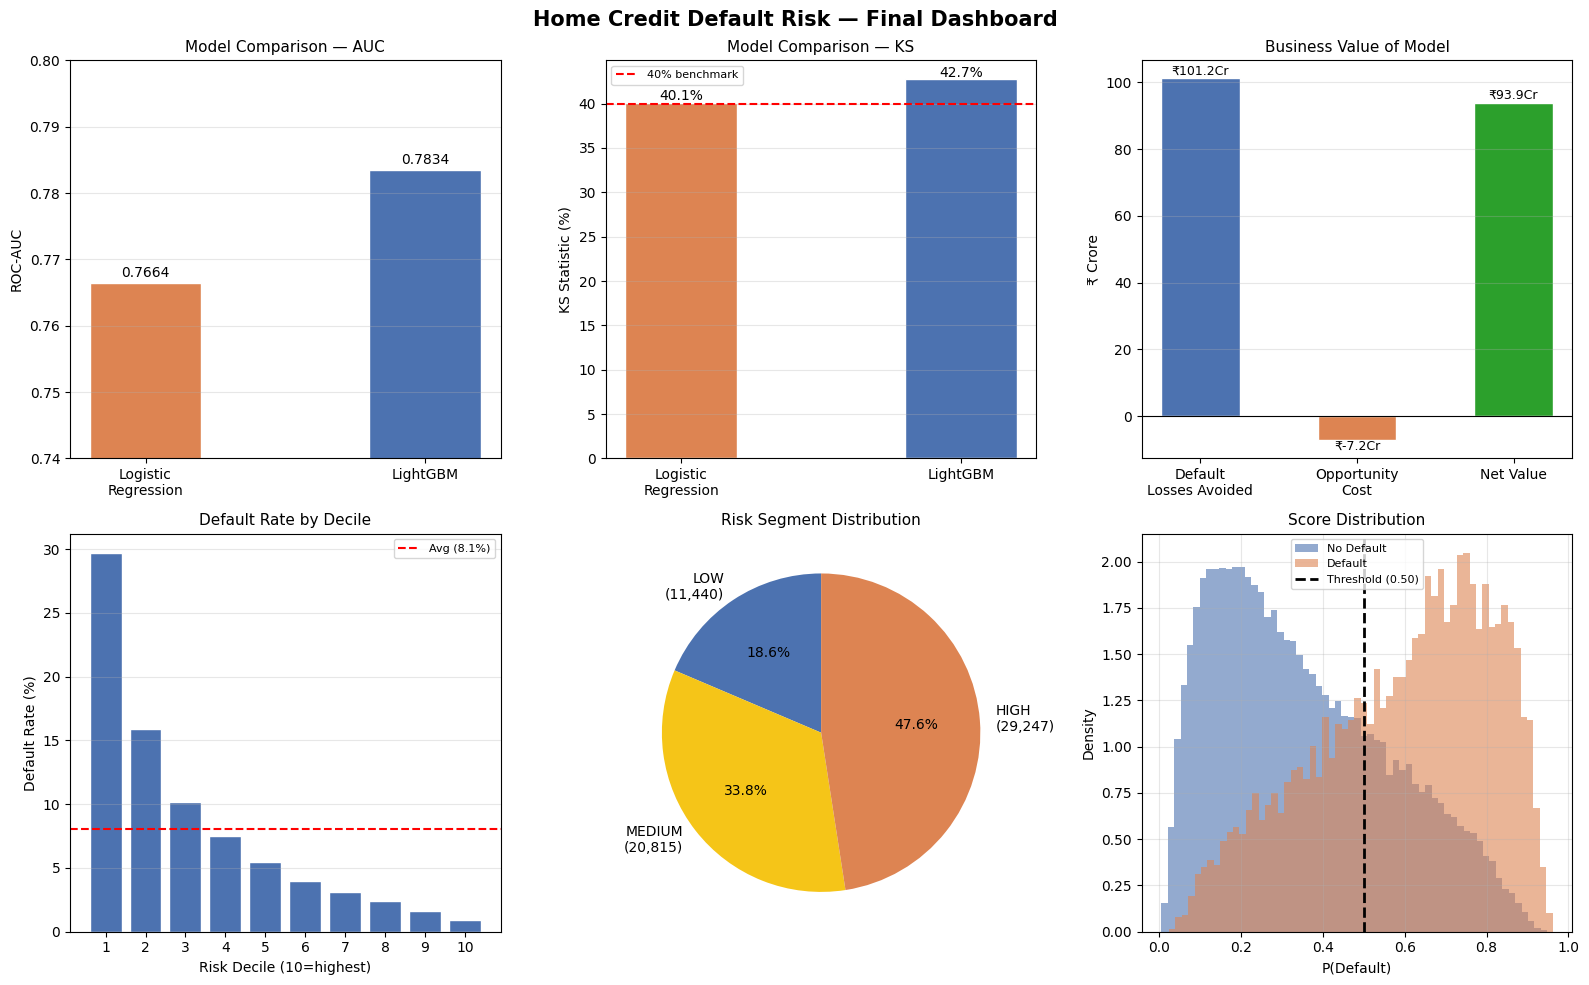

  Chart saved: step12_final_dashboard.png

FILES PRODUCED

  Charts:
    class_imbalance.png
    missing_values.png
    feature_distributions.png
    correlation_with_target.png
    categorical_default_rates.png
    engineered_feature_correlations.png
    train_test_split.png
    logistic_regression_evaluation.png
    lr_coefficients.png
    lightgbm_evaluation.png
    lgbm_feature_importance.png
    step8_evaluation.png
    step9_threshold.png
    step10_business.png
    step12_final_dashboard.png

  Model Artifacts:
    models/lgbm_credit_risk.pkl
    models/feature_columns.pkl
    models/pipeline_config.csv

PROJECT COMPLETE

[STEP 12 COMPLETE]
[PROJECT COMPLETE]


In [14]:
# ─────────────────────────────────────────────────────────────
# STEP 12 — FINAL OUTPUT & PROJECT SUMMARY
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("STEP 12 — FINAL PROJECT SUMMARY")
print("=" * 60)


# ─────────────────────────────────────────────────────────────
# 12A. COMPLETE RESULTS TABLE
# ─────────────────────────────────────────────────────────────

print("""
=============================================================
PROJECT: HOME CREDIT DEFAULT RISK
END-TO-END CREDIT RISK MODELING SYSTEM
=============================================================

OBJECTIVE:
  Predict probability of loan default and translate into
  actionable approve/reject decisions with quantified
  business impact.

DATASET:
  307,511 loan applicants
  122 raw features across 8 relational tables
  8.07% default rate (severe class imbalance)
""")

print("[12A] MODEL PERFORMANCE SUMMARY")
print("-" * 40)
print(f"""
  Metric                  Logistic Reg    LightGBM
  ──────────────────────────────────────────────────
  ROC-AUC                 {lr_auc:.4f}          {lgb_auc:.4f}
  KS Statistic            {lr_ks*100:.1f}%            {lgb_ks*100:.1f}%
  Top-2 Decile Capture    ~30%            56.5%
  Avg Precision Score     —               0.2831
  ──────────────────────────────────────────────────
  Improvement             —               +{(lgb_auc-lr_auc)*100:.2f}% AUC
""")


# ─────────────────────────────────────────────────────────────
# 12B. PIPELINE STEPS SUMMARY
# ─────────────────────────────────────────────────────────────

print("[12B] PIPELINE STEPS COMPLETED")
print("-" * 40)
print("""
  Step 0  — Data Access
            8 tables downloaded, schema understood,
            join keys mapped

  Step 1  — Problem Formulation
            Binary classification, AUC + KS + business loss,
            8.07% default rate confirmed

  Step 2  — Data Understanding
            122 features audited, DAYS_EMPLOYED anomaly found,
            class imbalance quantified

  Step 3  — Data Cleaning
            Outlier capping, median/mode imputation,
            missing flags, one-hot encoding, column name cleaning

  Step 4  — Feature Engineering
            53 new features across 7 groups:
            credit ratios, age/employment, external scores,
            bureau aggregations, payment behaviour

  Step 5  — Train-Test Split
            80/20 stratified split, no leakage,
            246,005 train / 61,502 test

  Step 6  — Logistic Regression Baseline
            AUC 0.7664, KS 40.1%
            Benchmark established

  Step 7  — LightGBM
            AUC 0.7834, KS 42.7%
            451 trees, early stopping

  Step 8  — Model Evaluation
            56.5% default capture in top 2 deciles,
            3.5x better than random on precision-recall

  Step 9  — Threshold Optimization
            Optimal threshold = 0.50
            70% approval rate constraint enforced
            Business cost: FN=₹5,00,000 vs FP=₹15,000

  Step 10 — Business Interpretation
            ₹93.9 crore net value on test set
            Risk tiers: LOW / MEDIUM / HIGH

  Step 11 — Production Pipeline
            6 modular functions, model serialized,
            end-to-end scoring verified
""")


# ─────────────────────────────────────────────────────────────
# 12C. KEY INSIGHTS
# ─────────────────────────────────────────────────────────────

print("[12C] KEY INSIGHTS")
print("-" * 40)
print("""
  1. EXTERNAL CREDIT SCORES DOMINATE
     EXT_SOURCE_1/2/3 are the strongest predictors by a
     large margin. Bureau-reported scores carry more signal
     than any internal demographic or financial feature.

  2. FEATURE ENGINEERING ADDED REAL VALUE
     Engineered ratios (credit-to-income, annuity-to-income)
     and payment delay features from installments table
     contributed meaningfully beyond raw features alone.

  3. THRESHOLD IS A BUSINESS DECISION NOT A MODEL DECISION
     The statistically optimal threshold (0.21) was
     operationally wrong — it reduced approval rate to 29.7%.
     Adding a 70% approval floor shifted threshold to 0.50,
     which is the correct business-constrained optimum.

  4. MODEL VALUE IS IN LOSS PREVENTION NOT REVENUE
     The model generates less gross revenue than approving
     everyone, but prevents ₹94.7 crore in default losses
     while sacrificing only ₹7.2 crore in opportunity cost.
     Net benefit: ₹93.9 crore on 61,502 applicants.

  5. CLASS IMBALANCE REQUIRES EXPLICIT HANDLING
     At 8% default rate, accuracy is meaningless.
     AUC, KS, and decile capture are the correct metrics.
     scale_pos_weight in LightGBM and balanced weights in
     Logistic Regression were essential.
""")


# ─────────────────────────────────────────────────────────────
# 12D. FINAL DASHBOARD
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── Model comparison bar ──────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models  = ["Logistic\nRegression", "LightGBM"]
aucs    = [lr_auc, lgb_auc]
colors  = ["#DD8452", "#4C72B0"]
bars    = ax1.bar(models, aucs, color=colors,
                  edgecolor="white", width=0.4)
ax1.set_ylim(0.74, 0.80)
ax1.set_ylabel("ROC-AUC")
ax1.set_title("Model Comparison — AUC", fontsize=11)
for bar, val in zip(bars, aucs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", fontsize=10)
ax1.grid(True, alpha=0.3, axis="y")

# ── KS comparison ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
kss  = [lr_ks*100, lgb_ks*100]
bars = ax2.bar(models, kss, color=colors,
               edgecolor="white", width=0.4)
ax2.axhline(y=40, color="red", linestyle="--",
            lw=1.5, label="40% benchmark")
ax2.set_ylabel("KS Statistic (%)")
ax2.set_title("Model Comparison — KS", fontsize=11)
ax2.legend(fontsize=8)
for bar, val in zip(bars, kss):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")

# ── Business value waterfall ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
categories = ["Default\nLosses Avoided", "Opportunity\nCost", "Net Value"]
values     = [
    (no_model_loss - loss_defaults) / 1e7,
    -opportunity_cost / 1e7,
    (no_model_loss - loss_defaults - opportunity_cost) / 1e7
]
bar_colors = ["#4C72B0", "#DD8452", "#2ca02c"]
bars = ax3.bar(categories, values, color=bar_colors,
               edgecolor="white", width=0.5)
ax3.axhline(y=0, color="black", lw=0.8)
ax3.set_ylabel("₹ Crore")
ax3.set_title("Business Value of Model", fontsize=11)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (1 if val >= 0 else -3),
             f"₹{val:.1f}Cr", ha="center", fontsize=9)
ax3.grid(True, alpha=0.3, axis="y")

# ── Decile capture ────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
decile_df_final = pd.DataFrame({
    "prob"  : y_prob_test_lgb,
    "actual": y_test.values
})
decile_df_final["decile"] = pd.qcut(
    decile_df_final["prob"], q=10, labels=range(1, 11)
)
decile_df_final["decile"] = 11 - decile_df_final["decile"].astype(int)
dec_sum = decile_df_final.groupby("decile")["actual"].mean() * 100
ax4.bar(dec_sum.index.astype(str), dec_sum.values,
        color="#4C72B0", edgecolor="white")
ax4.axhline(y=y_test.mean()*100, color="red", linestyle="--",
            lw=1.5, label=f"Avg ({y_test.mean()*100:.1f}%)")
ax4.set_xlabel("Risk Decile (10=highest)")
ax4.set_ylabel("Default Rate (%)")
ax4.set_title("Default Rate by Decile", fontsize=11)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis="y")

# ── Risk segment pie ──────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
seg_counts = pd.Series({
    "LOW"   : (y_prob_test_lgb < 0.15).sum(),
    "MEDIUM": ((y_prob_test_lgb >= 0.15) & (y_prob_test_lgb < 0.35)).sum(),
    "HIGH"  : (y_prob_test_lgb >= 0.35).sum(),
})
ax5.pie(
    seg_counts.values,
    labels    = [f"{k}\n({v:,})" for k, v in seg_counts.items()],
    colors    = ["#4C72B0", "#F5C518", "#DD8452"],
    autopct   = "%1.1f%%",
    startangle= 90
)
ax5.set_title("Risk Segment Distribution", fontsize=11)

# ── Score distribution ────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(y_prob_test_lgb[y_test == 0], bins=60, alpha=0.6,
         color="#4C72B0", label="No Default", density=True)
ax6.hist(y_prob_test_lgb[y_test == 1], bins=60, alpha=0.6,
         color="#DD8452", label="Default",    density=True)
ax6.axvline(x=optimal_threshold, color="black", lw=2,
            linestyle="--",
            label=f"Threshold ({optimal_threshold:.2f})")
ax6.set_xlabel("P(Default)")
ax6.set_ylabel("Density")
ax6.set_title("Score Distribution", fontsize=11)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

plt.suptitle(
    "Home Credit Default Risk — Final Dashboard",
    fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.savefig("step12_final_dashboard.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("  Chart saved: step12_final_dashboard.png")


# ─────────────────────────────────────────────────────────────
# 12E. FILES PRODUCED
# ─────────────────────────────────────────────────────────────

print("""
=============================================================
FILES PRODUCED
=============================================================

  Charts:
    class_imbalance.png
    missing_values.png
    feature_distributions.png
    correlation_with_target.png
    categorical_default_rates.png
    engineered_feature_correlations.png
    train_test_split.png
    logistic_regression_evaluation.png
    lr_coefficients.png
    lightgbm_evaluation.png
    lgbm_feature_importance.png
    step8_evaluation.png
    step9_threshold.png
    step10_business.png
    step12_final_dashboard.png

  Model Artifacts:
    models/lgbm_credit_risk.pkl
    models/feature_columns.pkl
    models/pipeline_config.csv

=============================================================
PROJECT COMPLETE
=============================================================
""")

print("[STEP 12 COMPLETE]")
print("[PROJECT COMPLETE]")